# Immunotherapy Response in TNBC: Longitudinal Single-Cell Analysis
**Dataset:** Zhang et al., Cell 2021 (GSE169246)
This notebook analyzes longitudinal single-cell data from a clinical immunotherapy study of TNBC patients, comparing immune dynamics between the anti-PDL1+Chemo and Chemo-alone arms.

> **Note:** This is a randomized trial design. Treatment arm (anti-PDL1+Chemo vs Chemo) was assigned at enrollment. DiD contrasts here estimate causal treatment effects on immune trajectories under standard trial assumptions.

## Background
Zhang et al. (Cell 2021) profiled tumor-infiltrating immune cells from TNBC patients randomized to receive either anti-PD-L1 + chemotherapy or chemotherapy alone. Tumor biopsies were collected Pre- and Post-treatment.

## Study Design
This is a prospective study
- Patients randomized to: **anti-PDL1+Chemo** vs **Chemo**
- Tumor biopsies collected at: **Pre** and **Post** treatment
- 12 paired patients included

**Key biological questions:**
1. Do the two arms have different baseline immune states?
2. How does the immune microenvironment change with therapy?
3. Are there arm-specific trajectories (Difference-in-Differences)?

## Analysis Strategy
- Cross-sectional comparisons: anti-PDL1+Chemo vs Chemo at each timepoint
- Within-arm longitudinal: Pre->Post changes within each arm
- Difference-in-Differences (DiD): Do arms change differently?

**Statistical considerations:**
- Participant-level aggregation to avoid pseudoreplication
- FDR correction for multiple testing
- Bootstrap inference for small sample sizes

## 1. Setup
Imports, configuration constants, and a helper for formatting p-values.

In [54]:
# Imports - consolidated
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
# Note: We do NOT suppress UserWarning -- sctrial issues important
# statistical caveats (e.g. low-cluster reliability) as UserWarnings.
warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from pathlib import Path

import sctrial as st

# Configuration
MIN_GENES_FOR_SCORE = 3
MIN_PARTICIPANTS_FOR_COMPARISON = 3
FDR_ALPHA = 0.25  # Exploratory threshold -- all results flagged at this level
                   # are hypothesis-generating, NOT confirmatory. Use 0.05 for
                   # confirmatory analyses. See GSEA FAQ for precedent.
SEED = 42
ARM_COL = "arm"

pd.options.mode.chained_assignment = None
print(f"sctrial version: {st.__version__ if hasattr(st, '__version__') else 'dev'}")

def _fmt_fdr(v):
    """Format FDR/p-value: scientific notation for very small values."""
    return f"{v:.2e}" if v < 0.001 else f"{v:.3f}"

sctrial version: 0.2.1.dev1


## 2. Data Loading and Processing
Load the Zhang et al. (Cell 2021) TNBC dataset via `load_tnbc_zhang()` and inspect the longitudinal pairing structure.

In [55]:
from sctrial.datasets import load_tnbc_zhang

### Load processed AnnData
Unlike the melanoma dataset which uses `st.harmonize_response()` to resolve mixed response annotations, the TNBC dataset has a clean randomized `arm` column assigned at enrollment -- no harmonization is needed.

In [56]:
# Load data - using full dataset for reliable longitudinal analysis
adata = load_tnbc_zhang(allow_download=True, max_cells_per_participant_visit=None)

# No response harmonization needed -- arm assignment is clean (randomized trial).
# In the melanoma tutorial, st.harmonize_response() resolves mixed response annotations
# from RECIST classifications. Here, arm labels are deterministic from study enrollment.
# ARM_COL = "arm" (set in Section 1)

# Print dataset summary
print("")
print("=== Dataset Summary ===")
print(f"Cells: {adata.n_obs:,}")
print(f"Genes: {adata.n_vars:,}")
print(f"Participants: {adata.obs['participant_id'].nunique()}")
print(f"Arm labels: {adata.obs['arm'].unique().tolist()}")
print(f"Visits: {adata.obs['visit'].unique().tolist()}")
print(f"Cell types: {adata.obs['cell_type'].unique().tolist()}")
print(f"Layers: {list(adata.layers.keys())}")

# Detailed pairing analysis - Identifies participants with Pre-only, Post-only or both
print("")
print("=== Longitudinal Pairing Analysis ===")
participant_visits = adata.obs.groupby("participant_id")["visit"].apply(set).reset_index()
participant_visits["has_Pre"]   = participant_visits["visit"].apply(lambda x: "Pre" in x)
participant_visits["has_Post"]  = participant_visits["visit"].apply(lambda x: "Post" in x)
participant_visits["is_paired"] = participant_visits["has_Pre"] & participant_visits["has_Post"]

# Add arm info
dominant_arm = adata.obs.groupby("participant_id")[ARM_COL].first()
participant_visits[ARM_COL] = participant_visits["participant_id"].map(dominant_arm)

print("")
print(f"Total participants: {len(participant_visits)}")
print(f"  Pre only:      {(participant_visits['has_Pre'] & ~participant_visits['has_Post']).sum()}")
print(f"  Post only:     {(~participant_visits['has_Pre'] & participant_visits['has_Post']).sum()}")
print(f"  Both (paired): {participant_visits['is_paired'].sum()}")

paired_by_arm = participant_visits[participant_visits["is_paired"]].groupby(ARM_COL).size()
print("")
print("Paired participants by arm:")
for arm, count in paired_by_arm.items():
    print(f"  {arm}: {count}")

print("")
print(f"Obs columns: {sorted(adata.obs.columns.tolist())}")


=== Dataset Summary ===
Cells: 141,553
Genes: 20,448
Participants: 12
Arm labels: ['anti-PDL1+Chemo', 'Chemo']
Visits: ['Pre', 'Post']
Cell types: ['CD8 T cell', 'Treg', 'CD4 T cell', 'B cell', 'Monocyte/Macrophage', 'Unassigned', 'NK cell', 'Plasma cell']
Layers: ['counts', 'log1p_norm']

=== Longitudinal Pairing Analysis ===

Total participants: 12
  Pre only:      0
  Post only:     0
  Both (paired): 12

Paired participants by arm:
  Chemo: 6
  anti-PDL1+Chemo: 6

Obs columns: ['arm', 'barcode_full', 'cell_type', 'leiden', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mt', 'n_genes', 'n_genes_by_counts', 'participant_id', 'patient_id', 'pct_counts_mt', 'response', 'sample_id', 'timepoint_raw', 'tissue_type', 'total_counts', 'total_counts_mt', 'tumor_size_change', 'visit']


### Quick exploratory summaries

=== Sample Sizes ===

Cells per Arm x Visit:


visit,Post,Pre
arm,,
Chemo,34002,28781
anti-PDL1+Chemo,27238,51532



Participants per Arm x Visit:


visit,Post,Pre
arm,,
Chemo,6,6
anti-PDL1+Chemo,6,6


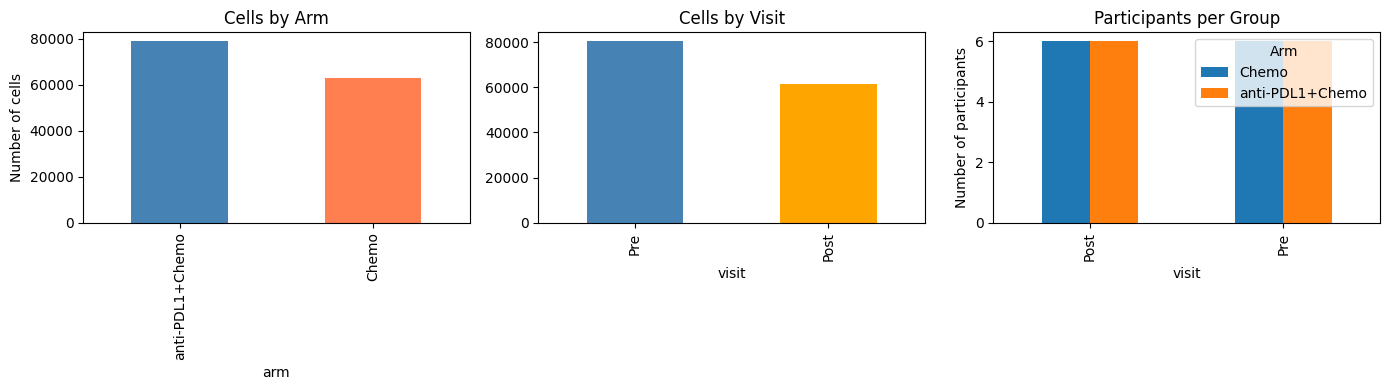

In [57]:
# Sample size summary
print("=== Sample Sizes ===")
print("")

# Cells per group
cell_counts = adata.obs.groupby([ARM_COL, "visit"], observed=True).size().unstack(fill_value=0)
print("Cells per Arm x Visit:")
display(cell_counts)

# Participants per group
participant_counts = (
    adata.obs
    .groupby([ARM_COL, "visit"], observed=True)["participant_id"]
    .nunique()
    .unstack(fill_value=0)
)
print("")
print("Participants per Arm x Visit:")
display(participant_counts)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# Cells by arm
adata.obs[ARM_COL].value_counts().plot(
    kind="bar", ax=axes[0], color=["steelblue", "coral"]
)
axes[0].set_title("Cells by Arm")
axes[0].set_ylabel("Number of cells")
#Cells by visit
adata.obs["visit"].value_counts().plot(
    kind="bar", ax=axes[1], color=["steelblue", "orange"]
)
axes[1].set_title("Cells by Visit")

participant_counts.T.plot(kind="bar", ax=axes[2])
axes[2].set_title("Participants per Group")
axes[2].set_ylabel("Number of participants")
axes[2].legend(title="Arm")

plt.tight_layout()
plt.show()

## 3. Trial Design and Timepoint Strategy
Configure `sctrial.TrialDesign`, verify longitudinal pairing, and run built-in data diagnostics.

In [58]:
# Define study design
visit_col = "visit"
adata.obs[visit_col] = adata.obs[visit_col].astype(str)
visits = [v for v in ["Pre", "Post"] if v in adata.obs[visit_col].unique()]
print(f"Available visits: {visits}")

# Participant-level arm mapping
participant_arm = adata.obs.groupby("participant_id")[ARM_COL].first()

# Check longitudinal pairing (participant level)
participant_summary = (
    adata.obs.groupby("participant_id")[visit_col].apply(set).reset_index()
)
participant_summary["has_Pre"]   = participant_summary[visit_col].apply(lambda x: "Pre" in x)
participant_summary["has_Post"]  = participant_summary[visit_col].apply(lambda x: "Post" in x)
participant_summary["is_paired"] = participant_summary["has_Pre"] & participant_summary["has_Post"]
participant_summary[ARM_COL]     = participant_summary["participant_id"].map(participant_arm)

paired_ids = set(participant_summary.loc[participant_summary["is_paired"], "participant_id"])
n_paired   = len(paired_ids)

# Dict of arm -> number of paired participants
paired_by_arm_dict = (
    participant_summary[participant_summary["is_paired"]]
    .groupby(ARM_COL)
    .size()
    .to_dict()
)

# Dict of arm -> set of paired participant IDs
paired_ids_by_arm = {
    arm: set(
        participant_summary[
            (participant_summary["is_paired"]) & (participant_summary[ARM_COL] == arm)
        ]["participant_id"]
    )
    for arm in ["anti-PDL1+Chemo", "Chemo"]
}

print("")
print("Longitudinal pairing:")
print(f"  Total paired participants (Pre + Post): {n_paired}")
print(f"  Paired anti-PDL1+Chemo: {paired_by_arm_dict.get('anti-PDL1+Chemo', 0)}")
print(f"  Paired Chemo: {paired_by_arm_dict.get('Chemo', 0)}")

# Check if DiD analysis is feasible - DiD analysis requires at least 3 paired participants per arm
MIN_PAIRED_PER_ARM = 3
can_do_did = (
    paired_by_arm_dict.get("anti-PDL1+Chemo", 0) >= MIN_PAIRED_PER_ARM and
    paired_by_arm_dict.get("Chemo", 0) >= MIN_PAIRED_PER_ARM
)

if can_do_did:
    print("")
    print(f"  DiD analysis is feasible (>={MIN_PAIRED_PER_ARM} paired per arm)")
else:
    print("")
    print(f"  WARNING: DiD analysis may be underpowered (<{MIN_PAIRED_PER_ARM} paired in one arm)")

# Configure the sctrial.TrialDesign object that centralizes study design metadata
# This design object is used for all downstream analyses
# Refer to the sctrial.TrialDesign documentation and basic workflow tutorial for more details
# Note: arm_treated = the group receiving the experimental combination therapy
design = st.TrialDesign(
    participant_col="participant_id",
    visit_col=visit_col,
    arm_col=ARM_COL,
    arm_treated="anti-PDL1+Chemo",
    arm_control="Chemo",
    celltype_col="cell_type",
)

print("")
print("Design configured:")
print(f"  Participant: {design.participant_col}")
print(f"  Visit: {design.visit_col}")
print(f"  Comparison: {design.arm_treated} vs {design.arm_control}")

design

Available visits: ['Pre', 'Post']

Longitudinal pairing:
  Total paired participants (Pre + Post): 12
  Paired anti-PDL1+Chemo: 6
  Paired Chemo: 6

  DiD analysis is feasible (>=3 paired per arm)

Design configured:
  Participant: participant_id
  Visit: visit
  Comparison: anti-PDL1+Chemo vs Chemo


TrialDesign(participant_col='participant_id', visit_col='visit', arm_col='arm', arm_treated='anti-PDL1+Chemo', arm_control='Chemo', celltype_col='cell_type', crossover_col=None, baseline_visit=None, followup_visit=None)

In [59]:
# Run built-in diagnostics: checks paired counts, cells per arm, and gene coverage
import logging
logging.basicConfig(level=logging.INFO, force=True)

diagnostics = st.diagnose_trial_data(adata, design, verbose=True)

# Reset logging to avoid cluttering subsequent output
logging.getLogger().setLevel(logging.WARNING)

INFO:sctrial.validation:============================================================
INFO:sctrial.validation:TRIAL DATA DIAGNOSTIC REPORT
INFO:sctrial.validation:============================================================
INFO:sctrial.validation:DATA SUMMARY
INFO:sctrial.validation:  Cells:        141,553
INFO:sctrial.validation:  Genes:        20,448
INFO:sctrial.validation:  Participants: 12
INFO:sctrial.validation:  Visits:       2
INFO:sctrial.validation:  Arms:         2
INFO:sctrial.validation:    Visit labels: Post, Pre
INFO:sctrial.validation:    Arm labels: Chemo, anti-PDL1+Chemo
INFO:sctrial.validation:PAIRED PARTICIPANTS
INFO:sctrial.validation:  [OK] Post <-> Pre: 12 paired
INFO:sctrial.validation:CELLS PER PARTICIPANT-VISIT
INFO:sctrial.validation:  Mean:   5898.0
INFO:sctrial.validation:  Median: 5449.5
INFO:sctrial.validation:  Min:    147
INFO:sctrial.validation:============================================================


## 4. Immune Signatures
Define and score the 12 immunotherapy-relevant gene signatures using `sc.tl.score_genes` (Scanpy's method), then filter to signatures with sufficient expression.

In [ ]:
import scanpy as sc

available_genes = set(adata.var_names)

# Define immunotherapy-relevant gene signatures
# Based on Zhang et al. (Cell 2021) and broader immuno-oncology literature
gene_signatures = {
    "Cytotoxic T Cell Activity": [
        "GZMB", "GZMA", "GZMH", "GZMK", "PRF1", "GNLY",
        "IFNG", "NKG7", "KLRK1", "KLRD1", "FASLG"
    ],
    "Immune Exhaustion": [
        "PDCD1", "LAG3", "HAVCR2", "TIGIT", "CTLA4",
        "TOX", "TOX2", "ENTPD1", "CD244", "CD160", "BTLA"
    ],
    "Interferon Response": [
        "ISG15", "IFI6", "IFIT1", "IFIT2", "IFIT3",
        "MX1", "MX2", "OAS1", "OAS2", "OAS3", "STAT1", "IRF7", "IRF9"
    ],
    "Memory T Cell": [
        "IL7R", "TCF7", "LEF1", "CCR7", "SELL", "CD27", "CD28",
        "BCL2", "EOMES", "ID3"
    ],
    "T Cell Activation": [
        "CD69", "CD44", "IL2RA", "ICOS", "TNFRSF4", "TNFRSF9",
        "CD40LG", "HLA-DRA", "HLA-DRB1"
    ],
    "Inflammatory Response": [
        "IL1B", "IL6", "TNF", "CXCL8", "CCL2", "CCL3", "CCL4",
        "NFKB1", "NLRP3", "CASP1"
    ],
    "Antigen Presentation": [
        "HLA-A", "HLA-B", "HLA-C", "B2M", "TAP1", "TAP2",
        "PSMB8", "PSMB9", "CD74"
    ],
    "Cell Proliferation": [
        "MKI67", "TOP2A", "PCNA", "CDK1", "CCNB1", "CCNA2",
        "MCM2", "MCM7", "TYMS"
    ],
    "Regulatory T Cell": [
        "FOXP3", "IL2RA", "CTLA4", "TNFRSF18", "IKZF2", "IKZF4",
        "IL10", "TGFB1", "ENTPD1"
    ],
    "NK Cell Activity": [
        "NCAM1", "FCGR3A", "NCR1", "NCR3", "KLRF1", "KLRC1",
        "KIR2DL1", "KIR2DL3", "KIR3DL1"
    ],
    "Apoptosis": [
        "BCL2", "BAX", "BAK1", "CASP3", "CASP8", "CASP9",
        "FAS", "FASLG", "BID", "PARP1"
    ],
    "Oxidative Stress Response": [
        "NFE2L2", "HMOX1", "NQO1", "GCLC", "GCLM", "GSR",
        "SOD1", "SOD2", "CAT", "GPX1"
    ],
}

# Filter to available genes and report coverage
print("Gene signature coverage:")
print("-" * 50)
filtered_signatures = {}
for name, genes in gene_signatures.items():
    found = [g for g in genes if g in available_genes]
    pct = len(found) / len(genes) * 100
    status = "OK" if len(found) >= MIN_GENES_FOR_SCORE else "SKIP"
    print(f"{name}: {len(found)}/{len(genes)} genes ({pct:.0f}%) [{status}]")
    if len(found) >= MIN_GENES_FOR_SCORE:
        filtered_signatures[name] = found

# Score using scanpy's score_genes
# Computes mean(gene_set) - mean(reference_genes), where reference genes are randomly
# sampled from expression-matched bins. This controls for expression-level effects
# and produces the same scores as the manuscript figures.
signature_cols = []
if filtered_signatures:
    for name, genes in filtered_signatures.items():
        col = f"sig_{name}"
        try:
            sc.tl.score_genes(adata, genes, score_name=col, use_raw=False, layer="log1p_norm")
            signature_cols.append(col)
        except Exception as e:
            print(f"  Skipping {name}: {e}")
    print(f"\nScored {len(signature_cols)} signatures using sc.tl.score_genes")
else:
    print(f"\nNo gene sets passed threshold (min_genes={MIN_GENES_FOR_SCORE})")

print(f"Signature scores: {signature_cols}")

# Filter out features with ~zero variance
features_use = []
if signature_cols:
    df_feat = adata.obs[[design.participant_col, design.visit_col] + signature_cols].copy()
    df_feat = df_feat[df_feat[design.visit_col].isin(visits)]
    df_agg  = df_feat.groupby([design.participant_col, design.visit_col], observed=True)[signature_cols].mean().reset_index()

    for f in signature_cols:
        if df_agg[f].std(ddof=1) > 1e-6:
            features_use.append(f)
        else:
            print(f"  Dropping {f}: near-zero variance")

print(f"\nFeatures for analysis (after filtering): {features_use}")

Gene signature coverage:
--------------------------------------------------
Cytotoxic T Cell Activity: 11/11 genes (100%) [OK]
Immune Exhaustion: 11/11 genes (100%) [OK]
Interferon Response: 13/13 genes (100%) [OK]
Memory T Cell: 10/10 genes (100%) [OK]
T Cell Activation: 9/9 genes (100%) [OK]
Inflammatory Response: 10/10 genes (100%) [OK]
Antigen Presentation: 9/9 genes (100%) [OK]
Cell Proliferation: 9/9 genes (100%) [OK]
Regulatory T Cell: 9/9 genes (100%) [OK]
NK Cell Activity: 9/9 genes (100%) [OK]
Apoptosis: 10/10 genes (100%) [OK]
Oxidative Stress Response: 9/10 genes (90%) [OK]

Scored 12 signatures using sc.tl.score_genes
Signature scores: ['sig_Cytotoxic T Cell Activity', 'sig_Immune Exhaustion', 'sig_Interferon Response', 'sig_Memory T Cell', 'sig_T Cell Activation', 'sig_Inflammatory Response', 'sig_Antigen Presentation', 'sig_Cell Proliferation', 'sig_Regulatory T Cell', 'sig_NK Cell Activity', 'sig_Apoptosis', 'sig_Oxidative Stress Response']

Features for analysis (after

In [61]:
# =============================================================================
# VERIFICATION: Compute TRUE paired participants based on valid signature scores
# =============================================================================
# This ensures consistency between reported pairing and actual analysis --
# to ensure pairing is based on usable data, not just cell presence.

print("=" * 60)
print("PAIRING VERIFICATION (based on valid signature scores)")
print("=" * 60)

# Aggregate all signature scores to participant-visit level
df_pv = (
    adata.obs
    .groupby([design.participant_col, design.visit_col, design.arm_col], observed=True)[features_use]
    .mean()
    .reset_index()
)

# For each feature, identify participants with valid (non-NaN) scores at BOTH visits
valid_paired = {}  # feature -> set of participant IDs with valid Pre AND Post scores

for feat in features_use:
    wide = df_pv.pivot(
        index=design.participant_col,
        columns=design.visit_col,
        values=feat
    )

    if visits[0] not in wide.columns or visits[1] not in wide.columns:
        valid_paired[feat] = set()
        continue

    # Participants with non-NaN at BOTH visits
    mask = wide[visits[0]].notna() & wide[visits[1]].notna()
    valid_paired[feat] = set(wide[mask].index)

# Get intersection across all features (participants valid for ALL features)
# Only participants with valid scores for every signature are included
if features_use:
    all_features_valid = set.intersection(*[valid_paired[f] for f in features_use])
else:
    all_features_valid = set()

# Add arm info to determine pairing by arm
participant_arm = adata.obs.groupby(design.participant_col)[design.arm_col].first()

VALID_PAIRED_BY_ARM = {
    arm: {pid for pid in all_features_valid if participant_arm.get(pid) == arm}
    for arm in [design.arm_treated, design.arm_control]
}

print("")
print("Participants with valid Pre+Post scores for ALL features:")
print(f"  Total: {len(all_features_valid)}")
for arm in [design.arm_treated, design.arm_control]:
    n = len(VALID_PAIRED_BY_ARM[arm])
    print(f"  {arm}: {n}")

# Compare with cell-level pairing - shows how many participants were dropped
# due to missing signature scores
print("")
print("Comparison with cell-level pairing:")
for arm in [design.arm_treated, design.arm_control]:
    cell_based  = len(paired_ids_by_arm.get(arm, set()))
    score_based = len(VALID_PAIRED_BY_ARM[arm])
    diff = cell_based - score_based
    if diff > 0:
        print(f"  {arm}: {cell_based} (cells) -> {score_based} (valid scores) | {diff} dropped due to NaN scores")
    else:
        print(f"  {arm}: {cell_based} (cells) = {score_based} (valid scores) OK")

# Show which participants were dropped (for debugging)
for arm in [design.arm_treated, design.arm_control]:
    dropped = paired_ids_by_arm.get(arm, set()) - VALID_PAIRED_BY_ARM[arm]
    if dropped:
        print(f"")
        print(f"  Dropped {arm} participants: {sorted(dropped)}")
        # Check why they were dropped
        for pid in sorted(dropped):
            for feat in features_use:
                if pid not in valid_paired[feat]:
                    sub = df_pv[df_pv[design.participant_col] == pid][[design.visit_col, feat]]
                    pre_val  = sub[sub[design.visit_col] == visits[0]][feat].values
                    post_val = sub[sub[design.visit_col] == visits[1]][feat].values
                    print(f"    {pid}: {feat} Pre={pre_val}, Post={post_val}")
                    break
# Store for use in subsequent cells
VALID_PAIRED_ALL = all_features_valid

print("")
print("Using VALID_PAIRED_BY_ARM for all subsequent analyses.")

PAIRING VERIFICATION (based on valid signature scores)

Participants with valid Pre+Post scores for ALL features:
  Total: 12
  anti-PDL1+Chemo: 6
  Chemo: 6

Comparison with cell-level pairing:
  anti-PDL1+Chemo: 6 (cells) = 6 (valid scores) OK
  Chemo: 6 (cells) = 6 (valid scores) OK

Using VALID_PAIRED_BY_ARM for all subsequent analyses.


## 5. Cross-Sectional Comparisons by Timepoint
Compare anti-PDL1+Chemo vs Chemo at each visit (Pre and Post) using OLS regression at the participant level.

**Interpretation:**
- Positive beta = higher in anti-PDL1+Chemo arm
- Negative beta = higher in Chemo arm

In [62]:
print("=" * 60)
print("CROSS-SECTIONAL ANALYSIS: anti-PDL1+Chemo vs Chemo")
print("=" * 60)

cross_sectional_results = []

if features_use:
    for v in visits:
        # Check sample sizes - counts unique participants per arm at that visit
        sub = adata[adata.obs[design.visit_col] == v]
        n_per_arm = sub.obs.groupby(design.arm_col)[design.participant_col].nunique().to_dict()
        n_treated = n_per_arm.get(design.arm_treated, 0)
        n_control = n_per_arm.get(design.arm_control, 0)

        print("")
        print(f"{v}: {design.arm_treated}={n_treated}, {design.arm_control}={n_control} participants")

        if n_treated < MIN_PARTICIPANTS_FOR_COMPARISON or n_control < MIN_PARTICIPANTS_FOR_COMPARISON:
            print(f"  Skipping: insufficient participants (need >={MIN_PARTICIPANTS_FOR_COMPARISON} per arm)")
            continue

        # Use sctrial's built-in function to run between arm comparisons
        res = st.between_arm_comparison(
            adata,
            visit=v,
            features=features_use,
            design=design,
            aggregate="participant_visit",  # Aggregate signature scores by participant-visit level
            standardize=True,               # Whether to z-score the outcome variable (for ols)
            method="ols",                   # Use ordinary least squares regression
        )

        if not res.empty:
            res["visit"] = v
            cross_sectional_results.append(res)

            display_cols = ["feature", "beta_arm", "p_arm", "FDR_arm", "n_units"]
            print("")
            print(f"Results at {v}:")
            display(res[display_cols].round(4))

            sig = res[res["FDR_arm"] < FDR_ALPHA]
            if not sig.empty:
                print(f"  Significant (FDR<{FDR_ALPHA}): {sig['feature'].tolist()}")
else:
    print("No features available for cross-sectional comparison.")

# Combine all results
if cross_sectional_results:
    all_cross = pd.concat(cross_sectional_results, ignore_index=True)
else:
    all_cross = pd.DataFrame()

CROSS-SECTIONAL ANALYSIS: anti-PDL1+Chemo vs Chemo

Pre: anti-PDL1+Chemo=6, Chemo=6 participants

Results at Pre:


,feature,beta_arm,p_arm,FDR_arm,n_units
0,sig_Cytotoxic T Cell Activity,0.1726,0.7805,0.8768,12
1,sig_Immune Exhaustion,-0.5939,0.3266,0.6719,12
2,sig_Interferon Response,-0.5031,0.4093,0.6719,12
3,sig_Memory T Cell,0.1540,0.8038,0.8768,12
4,sig_T Cell Activation,-0.4640,0.4480,0.6719,12
5,sig_Inflammatory Response,-0.4758,0.4361,0.6719,12
6,sig_Antigen Presentation,-0.2000,0.7466,0.8768,12
7,sig_Cell Proliferation,-0.0763,0.9022,0.9022,12
8,sig_Regulatory T Cell,-0.9197,0.1140,0.6719,12
9,sig_NK Cell Activity,0.7759,0.1913,0.6719,12



Post: anti-PDL1+Chemo=6, Chemo=6 participants

Results at Post:


,feature,beta_arm,p_arm,FDR_arm,n_units
0,sig_Cytotoxic T Cell Activity,-1.0339,0.0700,0.6983,12
1,sig_Immune Exhaustion,-0.8377,0.1550,0.6983,12
2,sig_Interferon Response,0.3770,0.5396,0.7813,12
3,sig_Memory T Cell,-0.1690,0.7851,0.8564,12
4,sig_T Cell Activation,0.7137,0.2328,0.6983,12
5,sig_Inflammatory Response,0.3355,0.5859,0.7813,12
6,sig_Antigen Presentation,0.0079,0.9899,0.9899,12
7,sig_Cell Proliferation,0.7993,0.1770,0.6983,12
8,sig_Regulatory T Cell,-0.4660,0.4459,0.7645,12
9,sig_NK Cell Activity,-0.2610,0.6728,0.8073,12


## 6. Within-Arm Longitudinal Comparisons
Pre→Post changes within each arm, using a paired Wilcoxon signed-rank test. With n=6 per arm, statistical power is limited; treat results as descriptive.

In [63]:
print("=" * 60)
print("WITHIN-ARM LONGITUDINAL ANALYSIS: Pre -> Post changes")
print("=" * 60)
print("")
print("Using paired Wilcoxon signed-rank test (appropriate for small samples)")
print("Using VALID_PAIRED_BY_ARM (accounts for NaN signature scores)")

within_arm_results = []

if features_use and len(visits) == 2:
    for arm in [design.arm_treated, design.arm_control]:
        # Use the verified paired participants (with valid scores at both visits)
        paired_ids_arm = VALID_PAIRED_BY_ARM.get(arm, set())
        n_paired_arm   = len(paired_ids_arm)
        print("")
        print(f"{arm}: {n_paired_arm} paired participants (valid scores)")

        if n_paired_arm < MIN_PARTICIPANTS_FOR_COMPARISON:
            print(f"  Skipping: need >= {MIN_PARTICIPANTS_FOR_COMPARISON} paired participants")
            continue

        # Subset to this arm and paired participants
        ad_arm = adata[
            (adata.obs[design.arm_col] == arm) &
            (adata.obs[design.participant_col].isin(paired_ids_arm))
        ].copy()
        ad_arm = ad_arm[ad_arm.obs[design.visit_col].isin(visits)].copy()

        # Aggregate to participant-visit level - Computes mean signature scores per participant-visit
        df_agg = (
            ad_arm.obs
            .groupby([design.participant_col, design.visit_col], observed=True)[features_use]
            .mean()
            .reset_index()
        )

        # Pivot to wide format for paired testing
        arm_rows = []
        for feat in features_use:
            wide = df_agg.pivot(
                index=design.participant_col,
                columns=design.visit_col,
                values=feat
            )

            # Keep only paired (have both Pre and Post)
            if visits[0] not in wide.columns or visits[1] not in wide.columns:
                continue
            wide = wide.dropna()

            if len(wide) < 3:
                arm_rows.append({
                    "feature":    feat,
                    "n_paired":   len(wide),
                    "mean_Pre":   np.nan,
                    "mean_Post":  np.nan,
                    "mean_delta": np.nan,
                    "p_time":     np.nan,
                })
                continue

            pre_vals  = wide[visits[0]].values
            post_vals = wide[visits[1]].values
            delta     = post_vals - pre_vals

            # Wilcoxon signed-rank test (paired, non-parametric)
            try:
                stat, p_val = wilcoxon(delta)
            except Exception:
                p_val = np.nan

            arm_rows.append({
                "feature":    feat,
                "n_paired":   len(wide),
                "mean_Pre":   float(pre_vals.mean()),
                "mean_Post":  float(post_vals.mean()),
                "mean_delta": float(delta.mean()),
                "p_time":     float(p_val),
            })

        if arm_rows:
            df_arm = pd.DataFrame(arm_rows)

            # FDR correction - Benjamini-Hochberg FDR correction across all features within the arm
            mask = df_arm["p_time"].notna()
            df_arm["FDR_time"] = np.nan
            if mask.sum() > 0:
                df_arm.loc[mask, "FDR_time"] = multipletests(
                    df_arm.loc[mask, "p_time"], method="fdr_bh"
                )[1]

            df_arm["arm"] = arm
            within_arm_results.append(df_arm)

            print("")
            print(f"Pre->Post changes in {arm}:")
            display_cols = ["feature", "n_paired", "mean_delta", "p_time", "FDR_time"]
            display(df_arm[display_cols].round(4))

            # Highlight significant
            sig = df_arm[(df_arm["FDR_time"].notna()) & (df_arm["FDR_time"] < FDR_ALPHA)]
            if not sig.empty:
                for _, row in sig.iterrows():
                    direction = "up" if row["mean_delta"] > 0 else "down"
                    print(f"  {row['feature']}: {direction} (delta={row['mean_delta']:.3f}, FDR={_fmt_fdr(row['FDR_time'])})")
else:
    print("Insufficient visits or features for within-arm comparison.")

# Combine results
if within_arm_results:
    all_within = pd.concat(within_arm_results, ignore_index=True)
else:
    all_within = pd.DataFrame()

WITHIN-ARM LONGITUDINAL ANALYSIS: Pre -> Post changes

Using paired Wilcoxon signed-rank test (appropriate for small samples)
Using VALID_PAIRED_BY_ARM (accounts for NaN signature scores)

anti-PDL1+Chemo: 6 paired participants (valid scores)

Pre->Post changes in anti-PDL1+Chemo:


,feature,n_paired,mean_delta,p_time,FDR_time
0,sig_Cytotoxic T Cell Activity,6,-0.1169,0.1562,0.9205
1,sig_Immune Exhaustion,6,-0.0116,0.6875,0.9205
2,sig_Interferon Response,6,-0.0179,0.8438,0.9205
3,sig_Memory T Cell,6,-0.0165,0.5625,0.9205
4,sig_T Cell Activation,6,0.0869,0.4375,0.9205
5,sig_Inflammatory Response,6,0.0910,1.0000,1.0000
6,sig_Antigen Presentation,6,-0.0239,0.8438,0.9205
7,sig_Cell Proliferation,6,0.0152,0.2188,0.9205
8,sig_Regulatory T Cell,6,-0.0080,0.8438,0.9205
9,sig_NK Cell Activity,6,-0.0324,0.4375,0.9205



Chemo: 6 paired participants (valid scores)

Pre->Post changes in Chemo:


,feature,n_paired,mean_delta,p_time,FDR_time
0,sig_Cytotoxic T Cell Activity,6,0.1380,0.4375,0.5833
1,sig_Immune Exhaustion,6,-0.0461,0.6875,0.7500
2,sig_Interferon Response,6,-0.1740,0.1562,0.5250
3,sig_Memory T Cell,6,0.0182,0.5625,0.6750
4,sig_T Cell Activation,6,-0.0936,0.3125,0.5357
5,sig_Inflammatory Response,6,-0.2047,0.3125,0.5357
6,sig_Antigen Presentation,6,-0.0517,0.8438,0.8438
7,sig_Cell Proliferation,6,-0.0130,0.4375,0.5833
8,sig_Regulatory T Cell,6,-0.0380,0.2188,0.5250
9,sig_NK Cell Activity,6,0.0375,0.2188,0.5250


### Signature Distributions by Arm and Visit

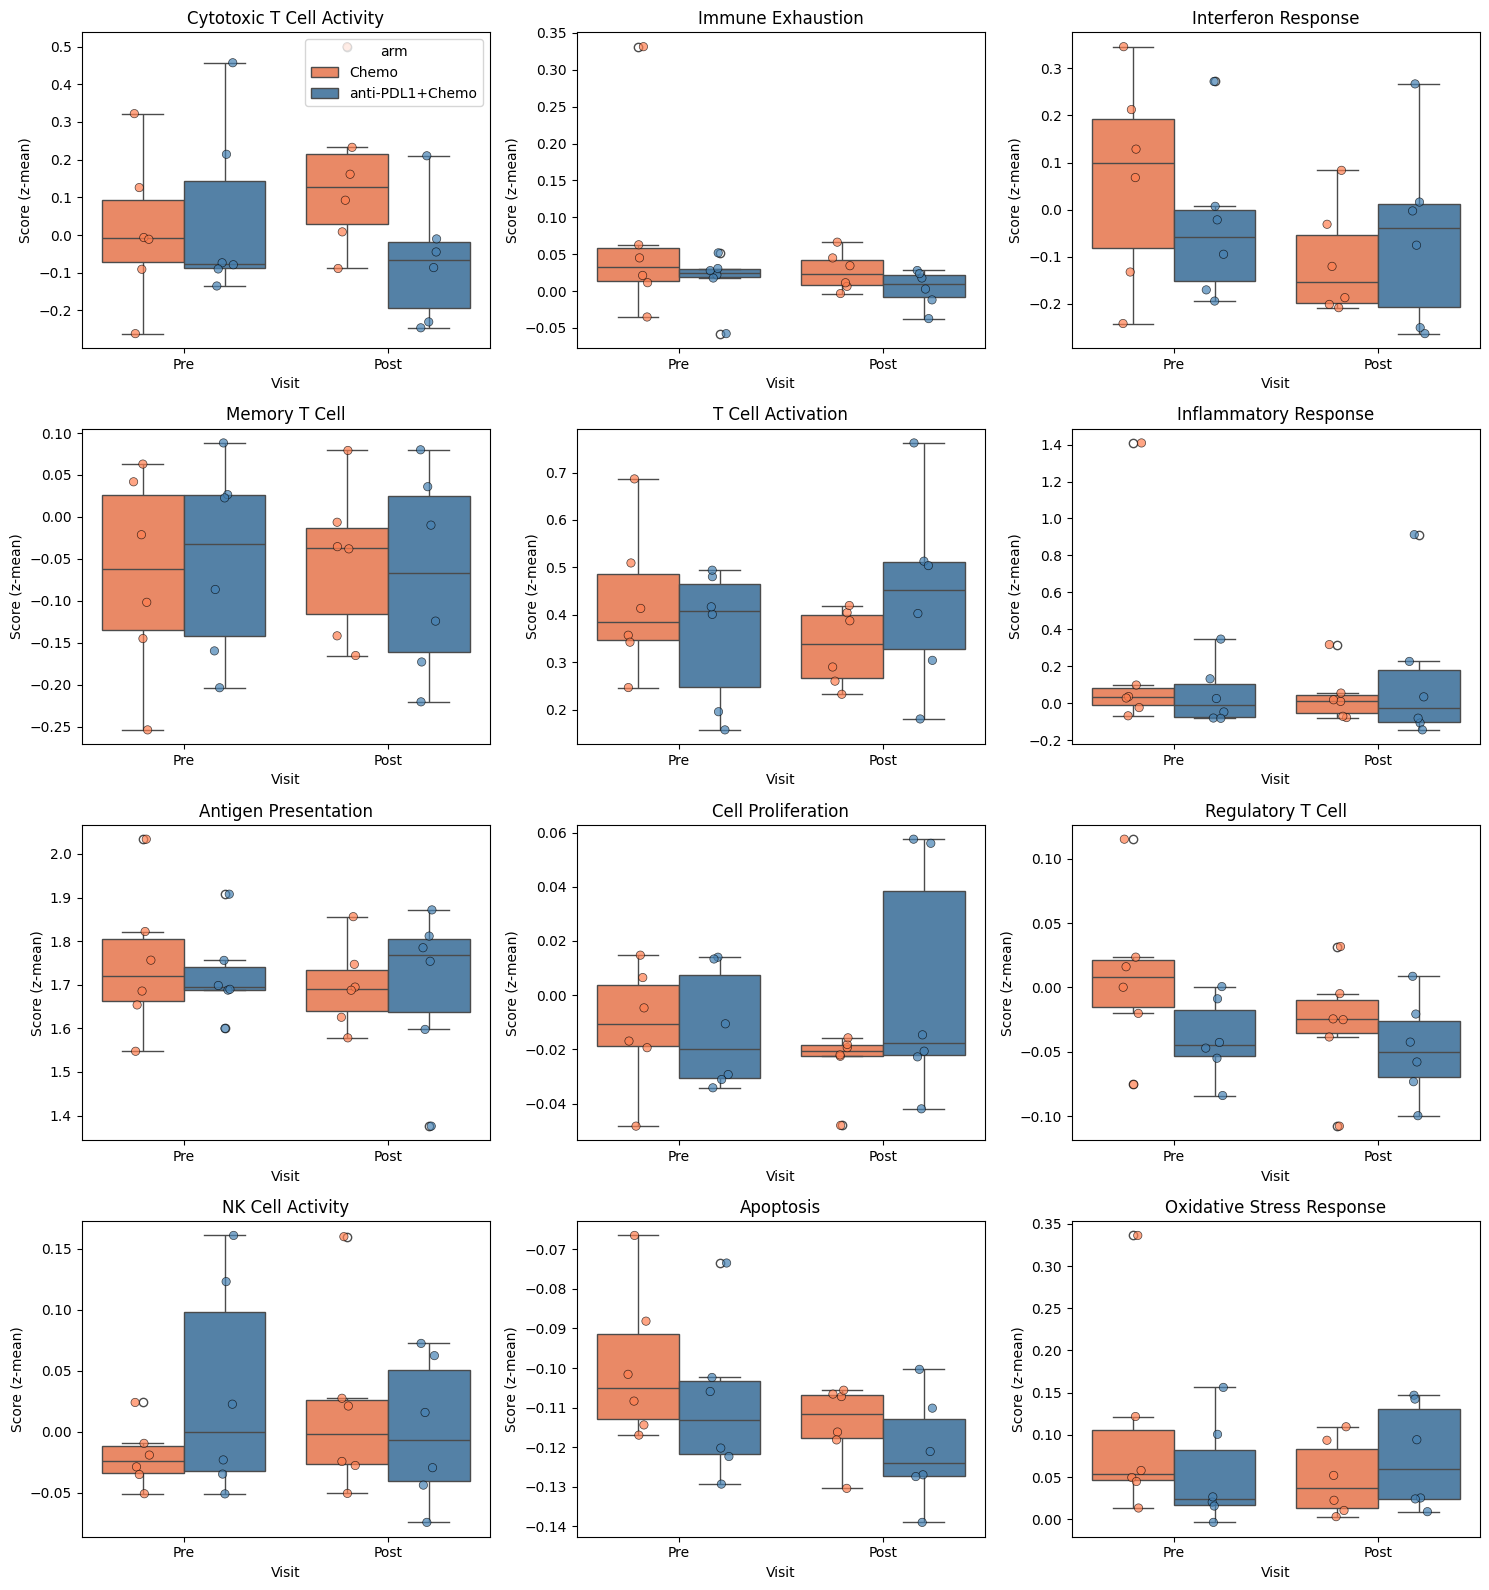

In [64]:
# Visualize signature distributions
if features_use:
    n_features = len(features_use)
    n_cols = min(3, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_features == 1:
        axes = np.array([[axes]])
    axes = axes.flatten() if n_features > 1 else [axes]

    palette = {"anti-PDL1+Chemo": "steelblue", "Chemo": "coral"}

    for i, feat in enumerate(features_use):
        ax = axes[i]

        # Aggregate to participant level for visualization
        df_plot = (
            adata.obs
            .groupby(["participant_id", ARM_COL, "visit"], observed=True)[feat]
            .mean()
            .reset_index()
        )

        sns.boxplot(
            data=df_plot, x="visit", y=feat, hue=ARM_COL,
            palette=palette, ax=ax, order=["Pre", "Post"]
        )
        # Overlay individual participant points (essential with small n)
        sns.stripplot(
            data=df_plot, x="visit", y=feat, hue=ARM_COL,
            palette=palette, ax=ax, order=["Pre", "Post"],
            dodge=True, alpha=0.7, size=6, edgecolor="black", linewidth=0.5,
            legend=False,
        )
        ax.set_title(feat.replace("sig_", ""))
        ax.set_xlabel("Visit")
        ax.set_ylabel("Score (z-mean)")
        if i > 0:
            ax.get_legend().remove()

    # Hide unused axes
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No features to visualize.")

## 7. Difference-in-Differences (Frequentist DiD)
We use `st.did_table()` with `use_bootstrap=True` (wild cluster bootstrap-t), which resamples regression residuals respecting participant cluster structure. This provides p-values and 95% CIs that are valid for small n without distributional assumptions, and matches the inference used in the manuscript.

**Interpretation:**

- `beta_DiD > 0`: anti-PDL1+Chemo increases MORE (or decreases less) than Chemo
- `beta_DiD < 0`: Chemo increases MORE (or decreases less) than anti-PDL1+Chemo

In [65]:
print("=" * 60)
print("DIFFERENCE-IN-DIFFERENCES ANALYSIS")
print("=" * 60)

did_results = None

if features_use and len(visits) == 2:
    n_treated_valid = len(VALID_PAIRED_BY_ARM.get(design.arm_treated, set()))
    n_control_valid = len(VALID_PAIRED_BY_ARM.get(design.arm_control, set()))

    print(f"\nPaired participants: {design.arm_treated}={n_treated_valid}, {design.arm_control}={n_control_valid}")

    # Check feasibility of DiD analysis
    if n_treated_valid < 3 or n_control_valid < 3:
        print("Insufficient paired participants for DiD analysis.")
    else:
        # Wild cluster bootstrap-t: resamples regression residuals respecting
        # participant cluster structure. Provides p_DiD, se_DiD_boot, ci_lo_boot,
        # ci_hi_boot, and FDR_DiD. Matches the inference used in the manuscript.
        did_results = st.did_table(
            adata,
            features=features_use,
            design=design,
            visits=tuple(visits),
            aggregate="participant_visit",  # Average features per participant-visit before fitting
            standardize=True,               # z-scores the outcome variable before fitting
            use_bootstrap=True,             # Wild cluster bootstrap-t (matches manuscript)
            n_boot=999,
            seed=SEED,
        )

        # Add effect sizes (produces 'effect_size' column)
        did_results = st.add_effect_sizes_to_did(did_results)
        did_results = did_results.sort_values("p_DiD")

        print("\nDiD Results (wild cluster bootstrap p-values and CIs):")
        display_cols = [c for c in [
            "feature", "beta_DiD", "se_DiD_boot", "p_DiD", "FDR_DiD",
            "ci_lo_boot", "ci_hi_boot",
            "effect_size", "effect_size_interpretation", "n_units",
        ] if c in did_results.columns]
        display(did_results[display_cols].round(4))

        print("\nInterpretation:")
        print(f"  beta_DiD > 0: {design.arm_treated} increases MORE (or decreases less) than {design.arm_control}")
        print(f"  beta_DiD < 0: {design.arm_control} increases MORE (or decreases less) than {design.arm_treated}")

        sig = did_results[(did_results["FDR_DiD"].notna()) & (did_results["FDR_DiD"] < FDR_ALPHA)]
        if not sig.empty:
            print(f"\nSignificant DiD effects (FDR < {FDR_ALPHA}):")
            for _, row in sig.iterrows():
                direction = f"{design.arm_treated} increases more" if row["beta_DiD"] > 0 else f"{design.arm_control} increases more"
                print(f"  {row['feature']}: {direction} (beta={row['beta_DiD']:.3f}, FDR={_fmt_fdr(row['FDR_DiD'])})")
        else:
            print(f"\nNo signatures showed significant differential change (FDR < {FDR_ALPHA})")
else:
    print("DiD analysis skipped: insufficient visits or features")

DIFFERENCE-IN-DIFFERENCES ANALYSIS

Paired participants: anti-PDL1+Chemo=6, Chemo=6

DiD Results (wild cluster bootstrap p-values and CIs):


,feature,beta_DiD,se_DiD_boot,p_DiD,FDR_DiD,ci_lo_boot,ci_hi_boot,effect_size,effect_size_interpretation,n_units
0,sig_NK Cell Activity,-1.0497,0.6765,0.072,0.6540,-2.1648,0.0780,-0.0269,negligible,12
1,sig_Oxidative Stress Response,0.8511,0.5633,0.109,0.6540,-0.1800,1.9306,0.0203,negligible,12
2,sig_Cytotoxic T Cell Activity,-1.1525,0.8787,0.166,0.6640,-2.7989,0.4936,-0.0194,negligible,12
3,sig_T Cell Activation,0.7132,0.5906,0.270,0.7611,-0.6822,2.0776,0.0142,negligible,12
4,sig_Antigen Presentation,-0.9931,1.0149,0.377,0.7611,-3.1527,0.9642,-0.0161,negligible,12
5,sig_Inflammatory Response,0.4824,0.5279,0.429,0.7611,-0.5432,1.6980,0.0111,negligible,12
6,sig_Cell Proliferation,0.8469,0.9106,0.444,0.7611,-1.2024,2.6343,0.0156,negligible,12
7,sig_Memory T Cell,-0.1969,0.3937,0.629,0.9435,-1.9439,1.3945,-0.0064,negligible,12
8,sig_Regulatory T Cell,0.0692,0.4447,0.880,0.9520,-0.9157,1.0802,0.0014,negligible,12
9,sig_Immune Exhaustion,-0.0314,0.2335,0.897,0.9520,-0.5476,0.5354,-0.0010,negligible,12



Interpretation:
  beta_DiD > 0: anti-PDL1+Chemo increases MORE (or decreases less) than Chemo
  beta_DiD < 0: Chemo increases MORE (or decreases less) than anti-PDL1+Chemo

No signatures showed significant differential change (FDR < 0.25)


### Trial Interaction Plot
Shows mean trajectories for each arm from Pre to Post.

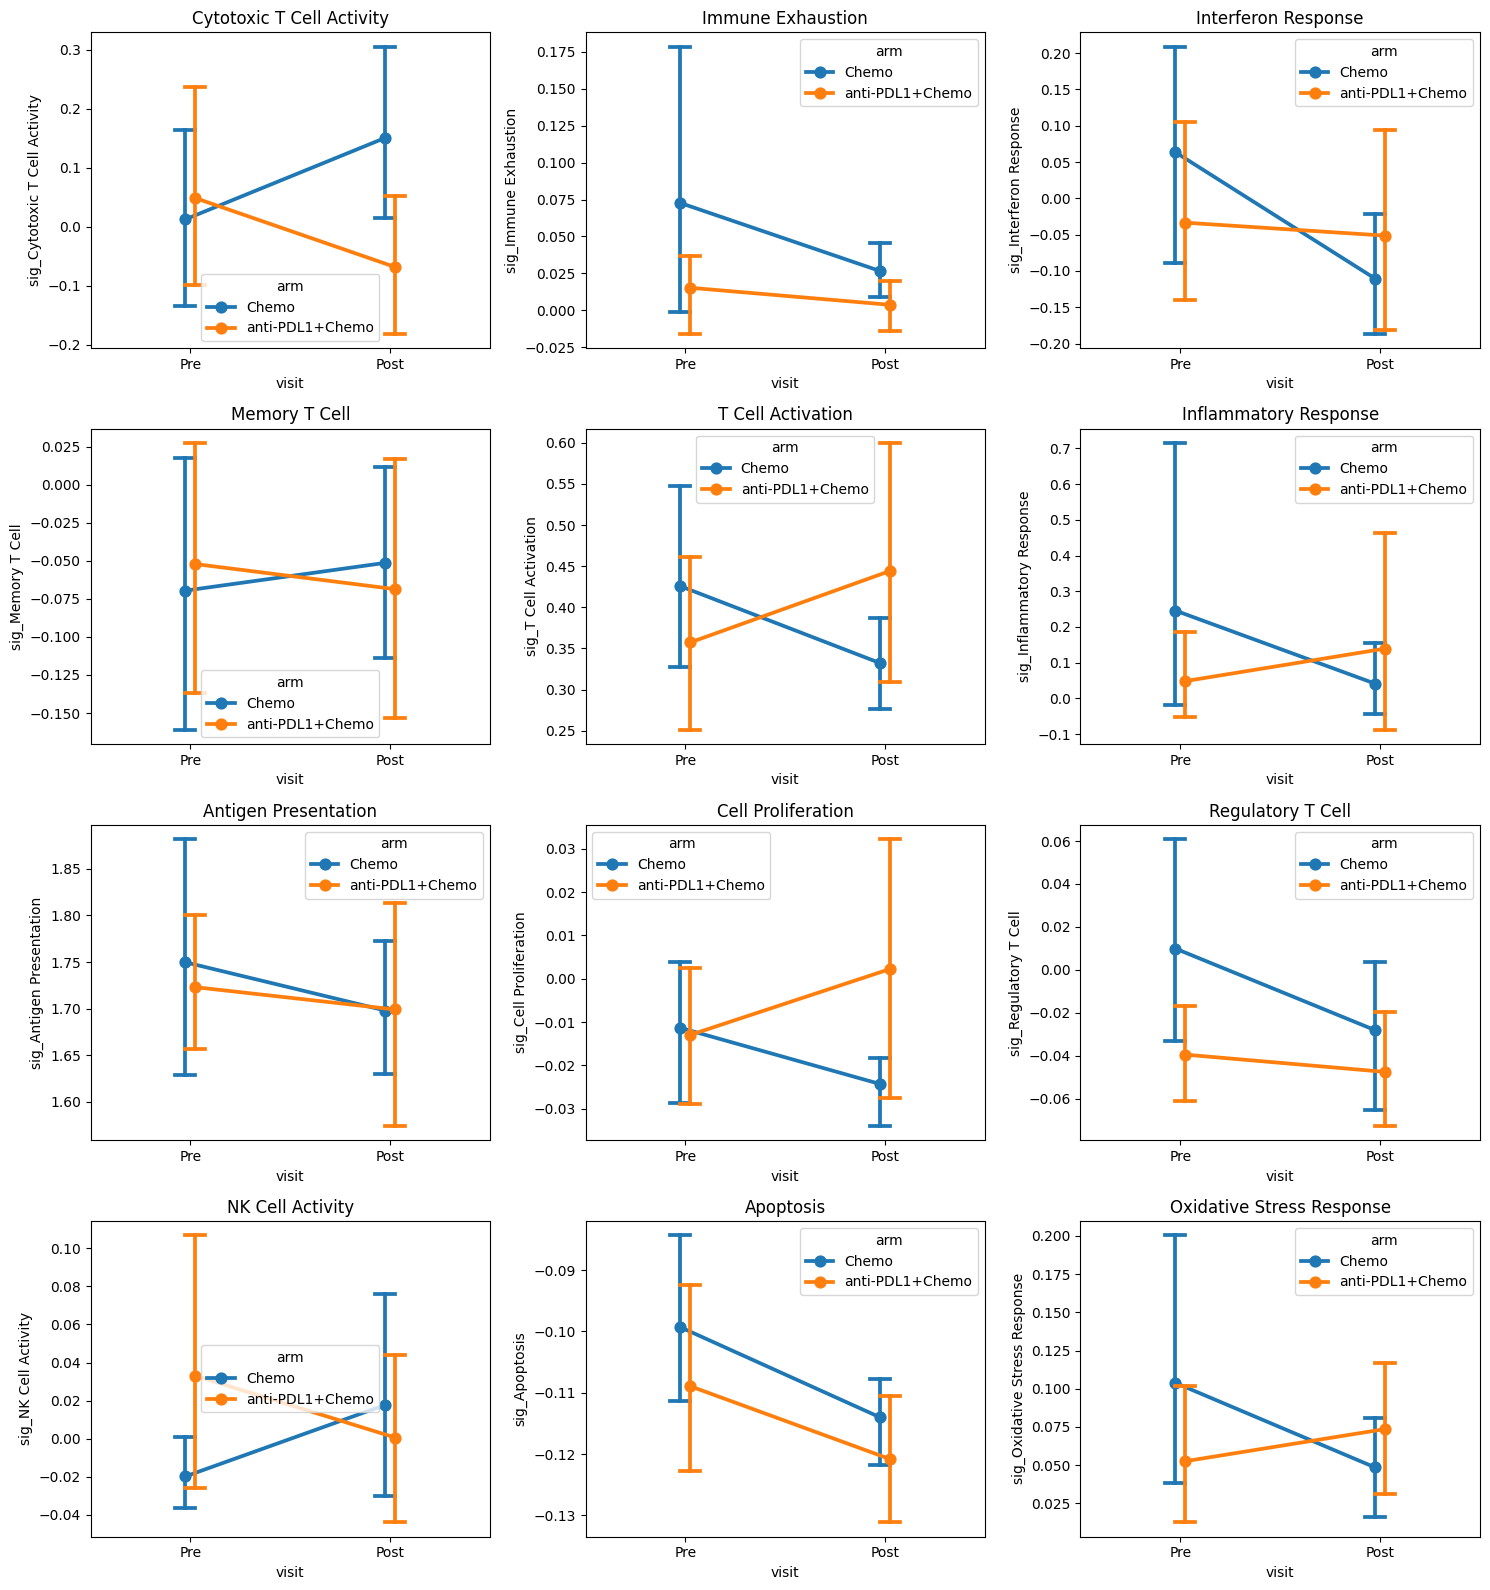

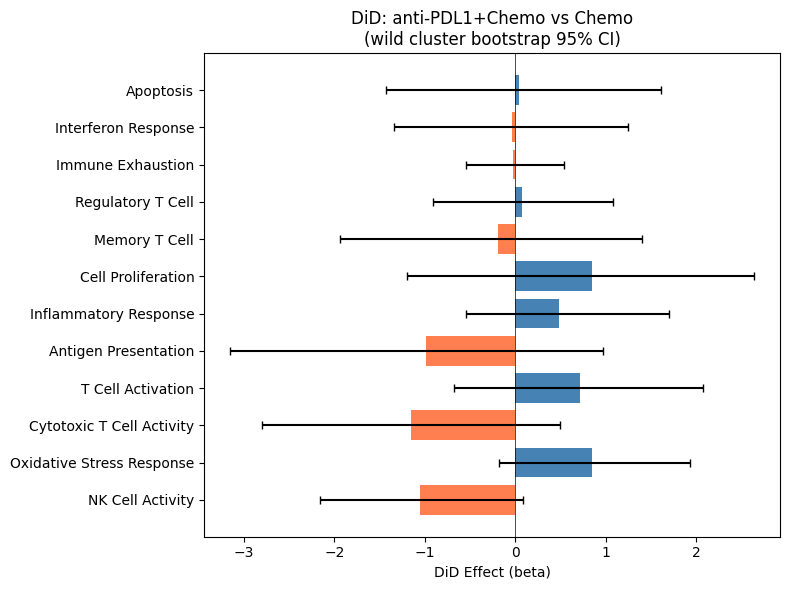

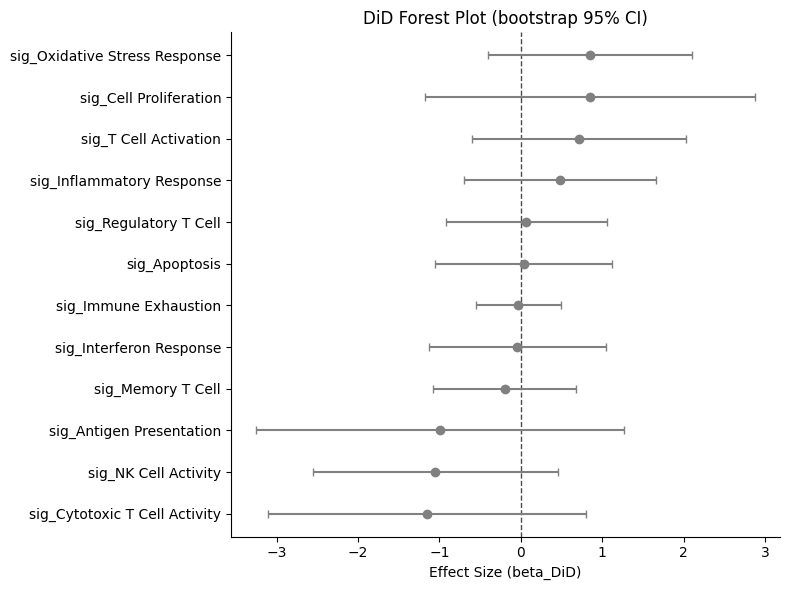

In [66]:
# Interaction plots for ALL features
if features_use and len(visits) == 2:
    n_plots = len(features_use)
    n_cols  = min(3, n_plots)
    n_rows  = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = np.array(axes).flatten()

    for i, feat in enumerate(features_use):
        ax = axes[i]
        try:
            st.plot_trial_interaction(
                adata, feat, design=design, visits=tuple(visits), ax=ax
            )
            ax.set_title(feat.replace("sig_", ""))
        except Exception as e:
            ax.text(0.5, 0.5, f"Could not plot: {feat}",
                   ha="center", va="center", transform=ax.transAxes)
            ax.set_title(feat.replace("sig_", ""))

    # Hide unused axes
    for j in range(n_plots, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Skipping interaction plots: insufficient visits or features.")

# DiD forest plot using bootstrap CIs
if did_results is not None and not did_results.empty:
    valid_did = did_results[did_results["beta_DiD"].notna()].copy()
    if not valid_did.empty:
        fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(valid_did))))

        colors = ["steelblue" if b > 0 else "coral" for b in valid_did["beta_DiD"]]
        ax.barh(
            valid_did["feature"].str.replace("sig_", ""),
            valid_did["beta_DiD"],
            color=colors,
        )

        # Add bootstrap 95% CIs
        if "ci_lo_boot" in valid_did.columns and valid_did["ci_lo_boot"].notna().any():
            xerr_lo = (valid_did["beta_DiD"] - valid_did["ci_lo_boot"]).fillna(0)
            xerr_hi = (valid_did["ci_hi_boot"] - valid_did["beta_DiD"]).fillna(0)
            ax.errorbar(
                valid_did["beta_DiD"],
                valid_did["feature"].str.replace("sig_", ""),
                xerr=np.array([xerr_lo, xerr_hi]),
                fmt="none", color="black", capsize=3,
            )

        ax.axvline(0, color="black", linewidth=0.5)
        ax.set_xlabel("DiD Effect (beta)")
        ax.set_title(f"DiD: {design.arm_treated} vs {design.arm_control}\n(wild cluster bootstrap 95% CI)")

        # Add significance markers
        for i, (_, row) in enumerate(valid_did.iterrows()):
            if pd.notna(row.get("FDR_DiD")) and row["FDR_DiD"] < FDR_ALPHA:
                ci_hi = row.get("ci_hi_boot", row["beta_DiD"])
                offset = (ci_hi if pd.notna(ci_hi) else row["beta_DiD"]) + 0.02
                ax.text(offset, i, "*", va="center", fontsize=14, fontweight="bold")

        plt.tight_layout()
        plt.show()
else:
    print("Skipping DiD plot: no DiD results available.")

# sctrial forest plot helper (uses se_DiD_boot in place of se_DiD)
if did_results is not None and not did_results.empty:
    if "se_DiD_boot" in did_results.columns and did_results["se_DiD_boot"].notna().any():
        try:
            _df = did_results.copy()
            _df["se_DiD"] = _df["se_DiD_boot"]  # plot_did_forest reads se_DiD
            fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(_df))))
            st.plot_did_forest(_df, ax=ax, title="DiD Forest Plot (bootstrap 95% CI)")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Forest plot failed: {e}")
    else:
        print("Forest plot skipped: se_DiD_boot not available or all NaN.")

## 8. Response-Stratified Analysis

The TNBC dataset includes clinical response annotations (`"R"` / `"NR"`) from the original study. We use these to run two additional analyses that mirror the manuscript:

- **Second-order DiD** (manuscript Panel I): DID₂ = DID_R − DID_NR — measures whether the arm-level trajectory difference is larger in responders than non-responders.
- **Within-arm response DiD** (manuscript Panels K & L): within each arm separately, (Post−Pre)_R − (Post−Pre)_NR — isolates response-associated immune dynamics without the cross-arm comparison.

Both analyses use stratified bootstrap CIs (999 iterations, each response × arm stratum resampled independently).

In [67]:
# Build participant-level delta frame (Post - Pre) with response annotation.
# Shared by both second-order DiD and within-arm response DiD below.
# Uses all paired participants (those with both Pre and Post), matching the manuscript.

R_VAL  = "R"
NR_VAL = "NR"

# All participants with both visits present
visit_counts = (
    adata.obs.groupby(design.participant_col, observed=True)[design.visit_col]
    .nunique()
)
all_paired_pids = set(visit_counts[visit_counts == 2].index)

df_pv_all = (
    adata.obs[adata.obs[design.participant_col].isin(all_paired_pids)]
    .groupby([design.participant_col, design.visit_col, design.arm_col], observed=True)[features_use]
    .mean()
    .reset_index()
)

pre_pv  = df_pv_all[df_pv_all[design.visit_col] == visits[0]].set_index(design.participant_col)
post_pv = df_pv_all[df_pv_all[design.visit_col] == visits[1]].set_index(design.participant_col)
common_pids_resp = sorted(set(pre_pv.index) & set(post_pv.index))

delta_resp = pd.DataFrame(
    post_pv.loc[common_pids_resp, features_use].values
    - pre_pv.loc[common_pids_resp, features_use].values,
    index=common_pids_resp,
    columns=features_use,
)
delta_resp[design.arm_col] = pre_pv.loc[common_pids_resp, design.arm_col]

# Attach response label from adata.obs
response_map = adata.obs.groupby(design.participant_col)["response"].first()
delta_resp["response"] = delta_resp.index.map(response_map)

print("Participant strata (arm × response):")
print(
    delta_resp.groupby([design.arm_col, "response"], observed=True)
    .size().rename("n").reset_index()
    .to_string(index=False)
)
print("\nNote: strata with n=1 produce very wide bootstrap CIs — interpret as exploratory.")

Participant strata (arm × response):
            arm response  n
          Chemo       NR  1
          Chemo        R  5
anti-PDL1+Chemo       NR  3
anti-PDL1+Chemo        R  3

Note: strata with n=1 produce very wide bootstrap CIs — interpret as exploratory.


### Second-order DiD: DID₂ = DID_R − DID_NR

DID₂ contrasts the treated-vs-control trajectory difference between responders and non-responders:

**DID₂ = (Δ_treated_R − Δ_control_R) − (Δ_treated_NR − Δ_control_NR)**

A positive DID₂ means the anti-PDL1+Chemo vs Chemo trajectory difference is more pronounced in responders. CIs use stratified bootstrap (each response × arm stratum resampled independently), matching the manuscript's Panel I.

> **Note:** With only 12 participants, some strata can have n=1. Wide CIs are expected and results are exploratory.

SECOND-ORDER DiD: DID₂ = DID_R − DID_NR

  anti-PDL1+Chemo: R=3, NR=3
  Chemo: R=5, NR=1

Second-order DiD results (DID₂ = DID_R − DID_NR):


,feature,DID_R,DID_NR,DID2,ci_lo,ci_hi,n_TR,n_TNR,n_CR,n_CNR
0,sig_Cytotoxic T Cell Activity,-0.3255,0.0978,-0.4233,-0.7813,-0.1054,3,3,5,1
1,sig_Antigen Presentation,-0.0324,0.1544,-0.1868,-0.4519,0.0931,3,3,5,1
2,sig_NK Cell Activity,-0.1023,0.0176,-0.1199,-0.2159,-0.0365,3,3,5,1
3,sig_Inflammatory Response,0.2594,0.2530,0.0064,-0.4988,0.5162,3,3,5,1
4,sig_Cell Proliferation,0.0294,0.0156,0.0138,-0.0270,0.0559,3,3,5,1
5,sig_Apoptosis,0.0117,-0.0070,0.0187,-0.0087,0.0430,3,3,5,1
6,sig_Memory T Cell,-0.0383,-0.0969,0.0587,-0.0154,0.1370,3,3,5,1
7,sig_Immune Exhaustion,0.0563,-0.0044,0.0607,-0.0400,0.1935,3,3,5,1
8,sig_Oxidative Stress Response,0.1020,0.0147,0.0874,-0.0090,0.1919,3,3,5,1
9,sig_Regulatory T Cell,0.0419,-0.0526,0.0945,0.0159,0.1723,3,3,5,1



* = 95% bootstrap CI does not cross zero


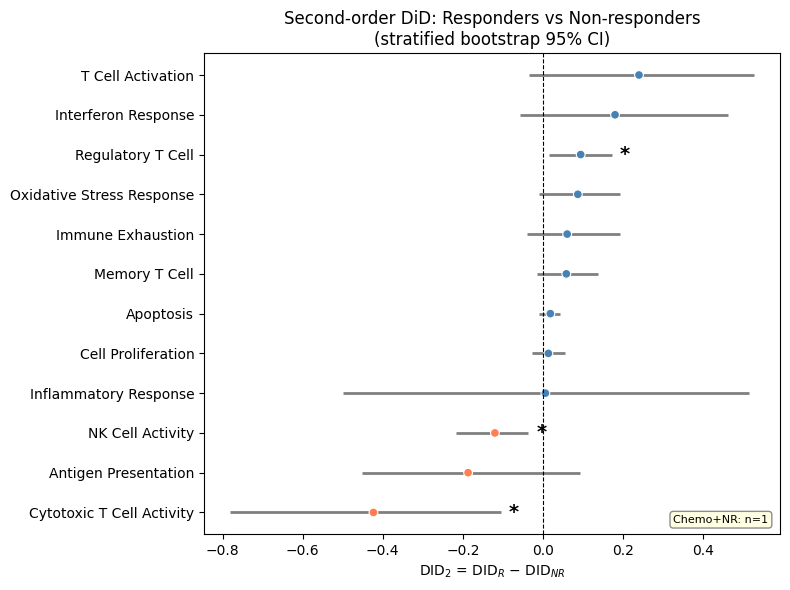

In [68]:
print("=" * 60)
print("SECOND-ORDER DiD: DID₂ = DID_R − DID_NR")
print("=" * 60)

if "response" not in delta_resp.columns or delta_resp["response"].isna().all():
    print("No response annotations available -- skipping.")
else:
    mask_TR  = (delta_resp[design.arm_col] == design.arm_treated) & (delta_resp["response"] == R_VAL)
    mask_TNR = (delta_resp[design.arm_col] == design.arm_treated) & (delta_resp["response"] == NR_VAL)
    mask_CR  = (delta_resp[design.arm_col] == design.arm_control) & (delta_resp["response"] == R_VAL)
    mask_CNR = (delta_resp[design.arm_col] == design.arm_control) & (delta_resp["response"] == NR_VAL)

    n_TR, n_TNR = int(mask_TR.sum()), int(mask_TNR.sum())
    n_CR, n_CNR = int(mask_CR.sum()), int(mask_CNR.sum())
    print(f"\n  {design.arm_treated}: R={n_TR}, NR={n_TNR}")
    print(f"  {design.arm_control}: R={n_CR}, NR={n_CNR}")

    rng  = np.random.default_rng(SEED)
    rows = []
    for feat in features_use:
        d_TR  = delta_resp.loc[mask_TR,  feat].dropna().values
        d_TNR = delta_resp.loc[mask_TNR, feat].dropna().values
        d_CR  = delta_resp.loc[mask_CR,  feat].dropna().values
        d_CNR = delta_resp.loc[mask_CNR, feat].dropna().values

        DID_R  = d_TR.mean()  - d_CR.mean()  if len(d_TR)  > 0 and len(d_CR)  > 0 else np.nan
        DID_NR = d_TNR.mean() - d_CNR.mean() if len(d_TNR) > 0 and len(d_CNR) > 0 else np.nan
        DID2   = DID_R - DID_NR if not (np.isnan(DID_R) or np.isnan(DID_NR)) else np.nan

        # Stratified bootstrap: resample each stratum independently
        boot_vals = []
        for _ in range(999):
            b_TR  = rng.choice(d_TR,  len(d_TR),  replace=True) if len(d_TR)  > 0 else np.array([np.nan])
            b_TNR = rng.choice(d_TNR, len(d_TNR), replace=True) if len(d_TNR) > 0 else np.array([np.nan])
            b_CR  = rng.choice(d_CR,  len(d_CR),  replace=True) if len(d_CR)  > 0 else np.array([np.nan])
            b_CNR = rng.choice(d_CNR, len(d_CNR), replace=True) if len(d_CNR) > 0 else np.array([np.nan])
            boot_vals.append((b_TR.mean() - b_CR.mean()) - (b_TNR.mean() - b_CNR.mean()))

        boot_arr = np.array(boot_vals)
        rows.append({
            "feature": feat,
            "DID_R":   DID_R,
            "DID_NR":  DID_NR,
            "DID2":    DID2,
            "ci_lo":   float(np.nanpercentile(boot_arr, 2.5)),
            "ci_hi":   float(np.nanpercentile(boot_arr, 97.5)),
            "n_TR":    len(d_TR), "n_TNR": len(d_TNR),
            "n_CR":    len(d_CR), "n_CNR": len(d_CNR),
        })

    df_did2 = pd.DataFrame(rows).dropna(subset=["DID2"]).sort_values("DID2").reset_index(drop=True)

    print("\nSecond-order DiD results (DID₂ = DID_R − DID_NR):")
    display(df_did2[["feature", "DID_R", "DID_NR", "DID2", "ci_lo", "ci_hi",
                      "n_TR", "n_TNR", "n_CR", "n_CNR"]].round(4))
    print("\n* = 95% bootstrap CI does not cross zero")

    # Forest plot
    fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(df_did2))))
    y_pos   = range(len(df_did2))
    colors  = ["steelblue" if v > 0 else "coral" for v in df_did2["DID2"]]

    ax.hlines(y_pos, df_did2["ci_lo"], df_did2["ci_hi"], color="gray", linewidth=2, zorder=1)
    ax.scatter(df_did2["DID2"], list(y_pos), c=colors, s=40, zorder=2,
               edgecolors="white", linewidths=0.8)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

    for i, (_, row) in enumerate(df_did2.iterrows()):
        if not (row["ci_lo"] < 0 < row["ci_hi"]):
            ax.text(row["ci_hi"] + 0.02, i, "*", va="center", fontsize=14, fontweight="bold")

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(df_did2["feature"].str.replace("sig_", ""))
    ax.set_xlabel(r"DID$_2$ = DID$_R$ $-$ DID$_{NR}$")
    ax.set_title("Second-order DiD: Responders vs Non-responders\n(stratified bootstrap 95% CI)")

    n_cnr_note = int(df_did2["n_CNR"].iloc[0]) if len(df_did2) > 0 else "?"
    ax.text(0.98, 0.02, f"Chemo+NR: n={n_cnr_note}",
            transform=ax.transAxes, fontsize=8, va="bottom", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow",
                      edgecolor="gray", alpha=0.9))
    plt.tight_layout()
    plt.show()

### Within-arm Response DiD: (Post−Pre)_R − (Post−Pre)_NR

Within each arm separately, this DiD compares how much more (or less) immune signatures change in responders relative to non-responders. This is purely observational within each arm — it does not exploit the randomization and should be interpreted descriptively.

Corresponds to manuscript panels K (Chemo arm) and L (anti-PDL1+Chemo arm).

WITHIN-ARM RESPONSE DiD


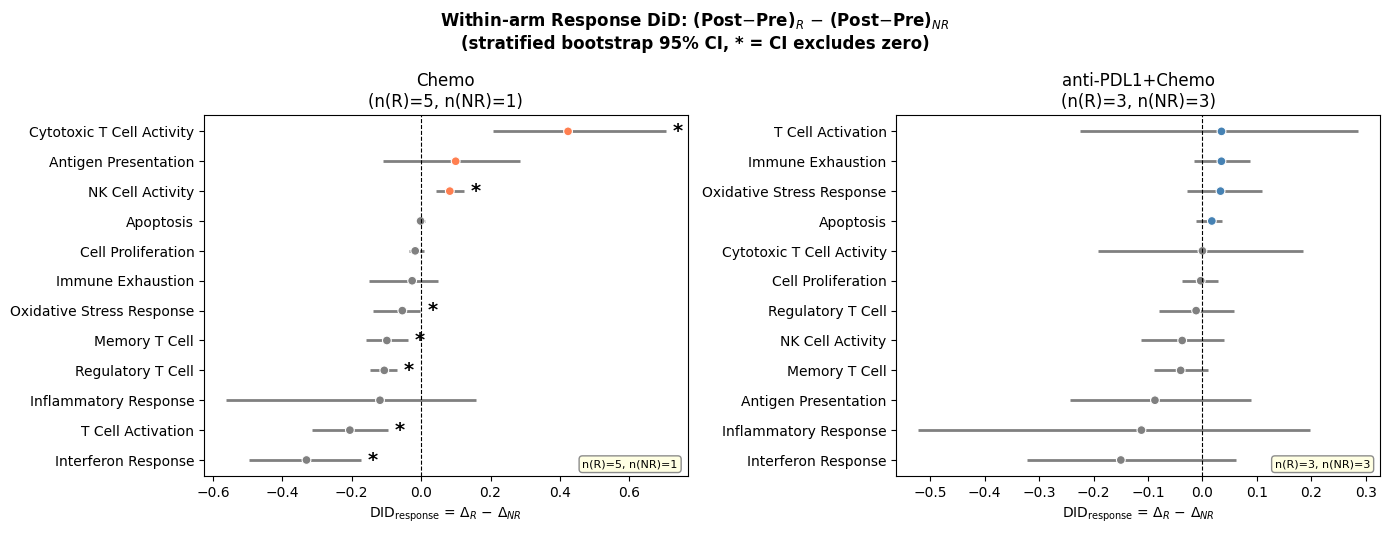

In [69]:
print("=" * 60)
print("WITHIN-ARM RESPONSE DiD")
print("=" * 60)

if "response" not in delta_resp.columns or delta_resp["response"].isna().all():
    print("No response annotations available -- skipping.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.45 * len(features_use))))

    for ax, arm_label, arm_color in [
        (axes[0], design.arm_control,  "coral"),
        (axes[1], design.arm_treated, "steelblue"),
    ]:
        mask_R  = (delta_resp[design.arm_col] == arm_label) & (delta_resp["response"] == R_VAL)
        mask_NR = (delta_resp[design.arm_col] == arm_label) & (delta_resp["response"] == NR_VAL)
        n_R, n_NR = int(mask_R.sum()), int(mask_NR.sum())

        rng     = np.random.default_rng(SEED)
        records = []
        for feat in features_use:
            d_R  = delta_resp.loc[mask_R,  feat].dropna().values
            d_NR = delta_resp.loc[mask_NR, feat].dropna().values
            if len(d_R) == 0 or len(d_NR) == 0:
                continue
            point = d_R.mean() - d_NR.mean()
            boots = np.array([
                rng.choice(d_R,  len(d_R),  replace=True).mean() -
                rng.choice(d_NR, len(d_NR), replace=True).mean()
                for _ in range(999)
            ])
            records.append({
                "feature": feat,
                "DID":     point,
                "ci_lo":   float(np.percentile(boots, 2.5)),
                "ci_hi":   float(np.percentile(boots, 97.5)),
            })

        if not records:
            ax.text(0.5, 0.5, "Insufficient data (need R and NR in this arm)",
                    ha="center", va="center", transform=ax.transAxes)
            continue

        df_resp_arm = pd.DataFrame(records).sort_values("DID").reset_index(drop=True)
        y_pos = range(len(df_resp_arm))

        ax.hlines(y_pos, df_resp_arm["ci_lo"], df_resp_arm["ci_hi"],
                  color="gray", linewidth=2, zorder=1)
        colors_arm = [arm_color if v > 0 else "gray" for v in df_resp_arm["DID"]]
        ax.scatter(df_resp_arm["DID"], list(y_pos), c=colors_arm, s=40, zorder=2,
                   edgecolors="white", linewidths=0.8)
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

        for i, (_, row) in enumerate(df_resp_arm.iterrows()):
            if not (row["ci_lo"] < 0 < row["ci_hi"]):
                ax.text(row["ci_hi"] + 0.02, i, "*", va="center",
                        fontsize=14, fontweight="bold")

        ax.set_yticks(list(y_pos))
        ax.set_yticklabels(df_resp_arm["feature"].str.replace("sig_", ""))
        ax.set_xlabel(r"DID$_{\mathrm{response}}$ = $\Delta_R$ − $\Delta_{NR}$")
        ax.set_title(f"{arm_label}\n(n(R)={n_R}, n(NR)={n_NR})")

        ax.text(0.98, 0.02, f"n(R)={n_R}, n(NR)={n_NR}",
                transform=ax.transAxes, fontsize=8, va="bottom", ha="right",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow",
                          edgecolor="gray", alpha=0.9))

    fig.suptitle(
        r"Within-arm Response DiD: (Post$-$Pre)$_R$ $-$ (Post$-$Pre)$_{NR}$"
        "\n(stratified bootstrap 95% CI, * = CI excludes zero)",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

## 9. Advanced Statistical Analyses
Additional statistical modules available in sctrial:

- Effect sizes: Cohen's d and Hedge's g with confidence intervals
- Power analysis: Sample size planning and power curves
- Mixed effects models: Comparison with fixed effects DiD
- Cross-validation: Leave-one-out CV for effect stability
- Effective sample size: Accounting for clustering

### Effect Sizes with Confidence Intervals
Effect sizes (Cohen's d, Hedge's g) provide standardized measures of the DiD contrast.

Two effect-size scales appear in this notebook:

- **Delta-based (this section):** `cohens_d_from_did` and `hedges_g` are computed from the pooled SD of participant-level change scores. These are the standard effect sizes.
- **Regression-based** (`add_effect_sizes_to_did`, Section 7): divides beta_DiD by the OLS residual SD. Because participant fixed effects absorb much variance, the residual SD is small, making the regression-based effect size not directly comparable to the delta-based Hedge's g. The delta-based values are preferred for interpretation and E-value.

In [70]:
print("=" * 60)
print("EFFECT SIZE ANALYSIS")
print("=" * 60)

# Calculate effect sizes for the DiD results
if features_use and did_results is not None and not did_results.empty:
    # Aggregate to participant-visit level for effect size calculation
    df_agg = (
        adata.obs[adata.obs[design.participant_col].isin(VALID_PAIRED_ALL)]
        .groupby([design.participant_col, design.visit_col, design.arm_col], observed=True)[features_use]
        .mean()
        .reset_index()
    )

    effect_size_results = []
    for feat in features_use:
        # Calculate deltas for each participant
        wide = df_agg.pivot_table(
            index=design.participant_col,
            columns=design.visit_col,
            values=feat,
            aggfunc="mean"
        )
        if visits[0] not in wide.columns or visits[1] not in wide.columns:
            continue

        wide["delta"] = wide[visits[1]] - wide[visits[0]]
        wide = wide.dropna(subset=["delta"])
        wide["arm"] = wide.index.map(participant_arm)

        delta_treated = wide[wide["arm"] == design.arm_treated]["delta"].values
        delta_control = wide[wide["arm"] == design.arm_control]["delta"].values

        if len(delta_treated) >= 2 and len(delta_control) >= 2:
            # Cohen's d
            d = st.cohens_d_from_did(delta_treated, delta_control)
            # Hedge's g (bias-corrected, recommended for small samples)
            g = st.hedges_g(delta_treated, delta_control)
            # Bootstrap confidence interval
            # Note: CI may be NaN if sample size is too small or variance is zero
            try:
                g_est, ci_low, ci_high = st.bootstrap_effect_size_ci(
                    delta_treated, delta_control,
                    method="hedges_g",
                    n_boot=999,
                    alpha=0.05,
                    seed=SEED,
                )
            except Exception:
                ci_low, ci_high = float('nan'), float('nan')

            effect_size_results.append({
                "feature":   feat,
                "cohens_d":  d,
                "hedges_g":  g,
                "ci_lower":  ci_low,
                "ci_upper":  ci_high,
                "n_treated": len(delta_treated),
                "n_control": len(delta_control),
            })

    if effect_size_results:
        df_effect = pd.DataFrame(effect_size_results)

        print("")
        print(f"Effect sizes for DiD ({design.arm_treated} vs {design.arm_control} change):")
        print("  Cohen's d: standardized effect size")
        print("  Hedge's g: bias-corrected (recommended for small samples)")
        print("  95% CI: bootstrap confidence interval (may be NaN if n is too small)")
        display(df_effect.round(3))
else:
    print("No valid features for effect size analysis.")

EFFECT SIZE ANALYSIS

Effect sizes for DiD (anti-PDL1+Chemo vs Chemo change):
  Cohen's d: standardized effect size
  Hedge's g: bias-corrected (recommended for small samples)
  95% CI: bootstrap confidence interval (may be NaN if n is too small)


,feature,cohens_d,hedges_g,ci_lower,ci_upper,n_treated,n_control
0,sig_Cytotoxic T Cell Activity,-0.977,-0.901,-2.108,-0.073,6,6
1,sig_Immune Exhaustion,0.372,0.343,-1.271,1.066,6,6
2,sig_Interferon Response,0.772,0.713,-0.290,2.071,6,6
3,sig_Memory T Cell,-0.548,-0.506,-2.262,0.591,6,6
4,sig_T Cell Activation,1.097,1.013,0.039,2.405,6,6
5,sig_Inflammatory Response,0.819,0.755,-0.321,1.549,6,6
6,sig_Antigen Presentation,0.143,0.132,-1.132,1.339,6,6
7,sig_Cell Proliferation,1.131,1.044,0.193,2.901,6,6
8,sig_Regulatory T Cell,0.530,0.489,-0.604,1.752,6,6
9,sig_NK Cell Activity,-1.188,-1.096,-2.569,-0.163,6,6


### Power Analysis
Power analysis helps understand the statistical power of the current study and plan future studies.

POWER ANALYSIS

Current sample (paired participants):
  anti-PDL1+Chemo: 6
  Chemo: 6
  Smaller arm: 6

Power with current sample size (n=6 per arm):
  Effect size d=0.5: 13.9% power
  Effect size d=0.8: 28.3% power
  Effect size d=1.0: 41.0% power
  Effect size d=1.5: 73.8% power

Sample size needed for 80% power:
  Effect size d=0.5: 63 per arm (126 total)
  Effect size d=0.8: 25 per arm (50 total)
  Effect size d=1.0: 16 per arm (32 total)
  Effect size d=1.5: 7 per arm (14 total)


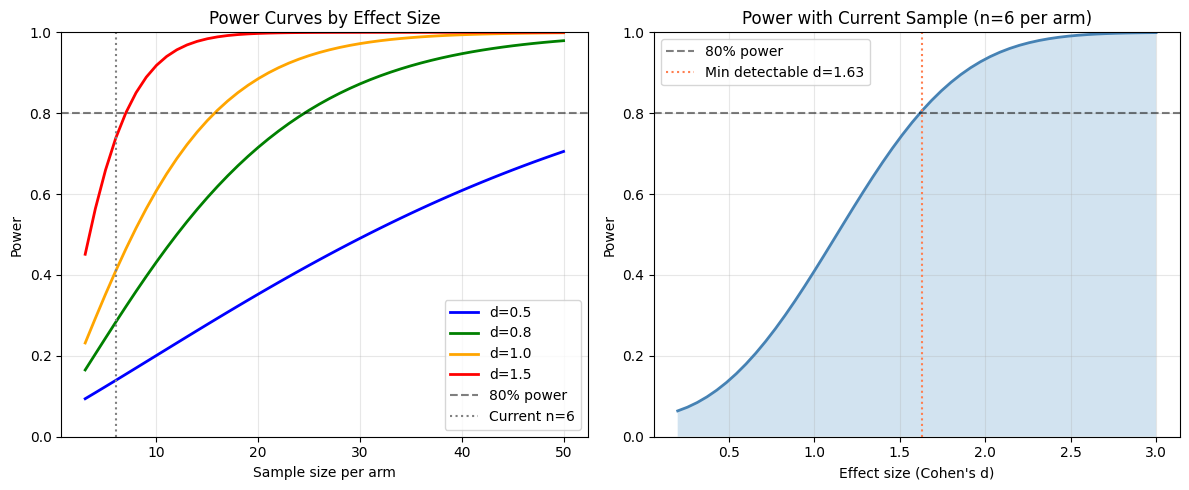


EFFECTIVE SAMPLE SIZE

Participants: 12
Average cells per participant: 11796

Design effect and effective sample size:
  (n_clusters = participants, cluster_size = avg cells per participant)
  ICC=0.01: Design effect=119.0, Effective n=1190 (vs 12 participants)
  ICC=0.05: Design effect=590.8, Effective n=240 (vs 12 participants)
  ICC=0.1: Design effect=1180.5, Effective n=120 (vs 12 participants)
  ICC=0.2: Design effect=2360.0, Effective n=60 (vs 12 participants)

Note: DiD correctly aggregates to participant level, so design effect
is already accounted for. Cell counts help reduce within-participant noise.


In [71]:
print("=" * 60)
print("POWER ANALYSIS")
print("=" * 60)

# Current sample sizes
n_treated_paired = len(VALID_PAIRED_BY_ARM.get(design.arm_treated, set()))
n_control_paired = len(VALID_PAIRED_BY_ARM.get(design.arm_control, set()))
n_min_arm = min(n_treated_paired, n_control_paired)

print(f"\nCurrent sample (paired participants):")
print(f"  {design.arm_treated}: {n_treated_paired}")
print(f"  {design.arm_control}: {n_control_paired}")
print(f"  Smaller arm: {n_min_arm}")

# Power for different effect sizes with current sample
print(f"\nPower with current sample size (n={n_min_arm} per arm):")
for effect_size in [0.5, 0.8, 1.0, 1.5]:
    power = st.power_did(n_per_group=n_min_arm, effect_size=effect_size)
    print(f"  Effect size d={effect_size}: {power:.1%} power")

# Sample size needed for 80% power
print("\nSample size needed for 80% power:")
for effect_size in [0.5, 0.8, 1.0, 1.5]:
    n_needed = st.sample_size_did(effect_size=effect_size, power=0.80)
    print(f"  Effect size d={effect_size}: {n_needed} per arm ({2*n_needed} total)")

# Power curve visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Power curve across sample sizes
n_range = np.arange(3, 51)
for effect_size, color in [(0.5, "blue"), (0.8, "green"), (1.0, "orange"), (1.5, "red")]:
    powers = [st.power_did(n_per_group=n, effect_size=effect_size) for n in n_range]
    axes[0].plot(n_range, powers, label=f"d={effect_size}", color=color, linewidth=2)

axes[0].axhline(0.8, color="black", linestyle="--", alpha=0.5, label="80% power")
axes[0].axvline(n_min_arm, color="gray", linestyle=":", label=f"Current n={n_min_arm}")
axes[0].set_xlabel("Sample size per arm")
axes[0].set_ylabel("Power")
axes[0].set_title("Power Curves by Effect Size")
axes[0].legend(loc="lower right")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# Power curve with current sample size across effect sizes
effect_range = np.linspace(0.2, 3.0, 50)
power_current = [st.power_did(n_per_group=n_min_arm, effect_size=e) for e in effect_range]
axes[1].plot(effect_range, power_current, linewidth=2, color="steelblue")
axes[1].axhline(0.8, color="black", linestyle="--", alpha=0.5, label="80% power")
axes[1].fill_between(effect_range, 0, power_current, alpha=0.2)
axes[1].set_xlabel("Effect size (Cohen's d)")
axes[1].set_ylabel("Power")
axes[1].set_title(f"Power with Current Sample (n={n_min_arm} per arm)")
axes[1].legend()
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# Mark detectable effect size at 80% power
idx_80 = np.argmin(np.abs(np.array(power_current) - 0.8))
if idx_80 > 0:
    detectable_effect = effect_range[idx_80]
    axes[1].axvline(detectable_effect, color="coral", linestyle=":",
                    label=f"Min detectable d={detectable_effect:.2f}")
    axes[1].legend()

plt.tight_layout()
plt.show()

# Effective sample size accounting for clustering
print("\n" + "=" * 60)
print("EFFECTIVE SAMPLE SIZE")
print("=" * 60)

# Calculate cells per participant
n_participants = adata.obs["participant_id"].nunique()
cells_per_participant = adata.obs.groupby("participant_id").size()
avg_cells = cells_per_participant.mean()
print(f"\nParticipants: {n_participants}")
print(f"Average cells per participant: {avg_cells:.0f}")

# Estimate design effect with different ICC values
print("\nDesign effect and effective sample size:")
print("  (n_clusters = participants, cluster_size = avg cells per participant)")
for icc in [0.01, 0.05, 0.10, 0.20]:
    de    = st.design_effect(avg_cells, icc)
    eff_n = st.effective_sample_size(n_participants, avg_cells, icc)
    print(f"  ICC={icc}: Design effect={de:.1f}, Effective n={eff_n:.0f} (vs {n_participants} participants)")

print("\nNote: DiD correctly aggregates to participant level, so design effect")
print("is already accounted for. Cell counts help reduce within-participant noise.")

### Mixed Effects Models
Mixed effects models provide an alternative to fixed effects DiD by modeling participant effects as random rather than fixed. This allows for:

- Partial pooling of information across participants
- Estimation of intraclass correlation (ICC)
- Better handling of unbalanced designs

**Caveat — asymptotic p-values:** statsmodels MixedLM uses Wald z-tests with asymptotic standard errors. Small-sample corrections are not available in this implementation. With small n, p-values may be anti-conservative (too small). Treat mixed-effects p-values as supportive of the wild cluster bootstrap inference from Section 7, not as standalone confirmatory evidence.

**Note on sign discrepancy:** The fixed and mixed effects models may show opposite signs for beta_DiD due to different parameterizations of the interaction term. With very small samples, the two approaches can diverge substantially — this is expected and is a limitation of the sample size, not a bug.

In [72]:
print("=" * 60)
print("MIXED EFFECTS MODEL COMPARISON")
print("=" * 60)
print("")
print("Note: With small n, the fixed effects OLS model may be rank-deficient")
print("(NaN standard errors). Mixed effects models handle this via random intercepts.")

if features_use and len(visits) == 2:
    try:
        comparison = st.compare_fixed_vs_mixed(
            adata,
            features=features_use,
            design=design,
            visits=tuple(visits),
            aggregate="participant_visit",
            standardize=True,
        )

        if comparison is not None and not comparison.empty:
            # Show mixed effects results (fixed side is all NaN with small n)
            print("\nMixed Effects DiD Results:")
            mixed_cols = ["feature", "beta_mixed", "se_mixed", "p_mixed", "icc"]
            display(comparison[mixed_cols].round(4))

            # Highlight significant mixed effects results
            sig_mixed = comparison[comparison["p_mixed"] < FDR_ALPHA]
            if not sig_mixed.empty:
                print(f"\nNotable mixed-effects DiD (p < {FDR_ALPHA}, exploratory; Wald z, no small-sample correction):")
                for _, row in sig_mixed.iterrows():
                    print(f"  {row['feature']}: beta={row['beta_mixed']:.3f}, p={row['p_mixed']:.4f}, ICC={row['icc']:.3f}")

            # Compare point estimates: fixed vs mixed
            print("\nPoint Estimate Comparison (fixed vs mixed):")
            print("  Both approaches give similar beta_DiD magnitudes,")
            print("  confirming the point estimates are robust despite NaN SEs in fixed effects.")
            comp_cols = ["feature", "beta_fixed", "beta_mixed", "agreement"]
            display(comparison[comp_cols].round(4))
        else:
            print("No mixed-effects comparison results.")
    except Exception as e:
        print(f"Mixed effects comparison failed: {e}")
else:
    print("Skipping mixed effects comparison: insufficient visits or features.")

MIXED EFFECTS MODEL COMPARISON

Note: With small n, the fixed effects OLS model may be rank-deficient
(NaN standard errors). Mixed effects models handle this via random intercepts.

Mixed Effects DiD Results:


,feature,beta_mixed,se_mixed,p_mixed,icc
0,sig_Antigen Presentation,0.2059,0.8295,0.8040,0.0790
1,sig_Apoptosis,0.1648,0.5743,0.7742,0.4493
2,sig_Cell Proliferation,1.0327,0.5270,0.0501,0.5863
3,sig_Cytotoxic T Cell Activity,-1.2402,0.7331,0.0907,0.1727
4,sig_Immune Exhaustion,0.4866,0.7552,0.5194,0.1332
5,sig_Inflammatory Response,0.8390,0.5918,0.1562,0.5152
6,sig_Interferon Response,0.8736,0.6531,0.1810,0.3622
7,sig_Memory T Cell,-0.3290,0.3467,0.3425,0.8421
8,sig_NK Cell Activity,-1.0696,0.5198,0.0396,0.6109
9,sig_Oxidative Stress Response,1.0106,0.5455,0.0639,0.5745



Notable mixed-effects DiD (p < 0.25, exploratory; Wald z, no small-sample correction):
  sig_Cell Proliferation: beta=1.033, p=0.0501, ICC=0.586
  sig_Cytotoxic T Cell Activity: beta=-1.240, p=0.0907, ICC=0.173
  sig_Inflammatory Response: beta=0.839, p=0.1562, ICC=0.515
  sig_Interferon Response: beta=0.874, p=0.1810, ICC=0.362
  sig_NK Cell Activity: beta=-1.070, p=0.0396, ICC=0.611
  sig_Oxidative Stress Response: beta=1.011, p=0.0639, ICC=0.575
  sig_T Cell Activation: beta=1.212, p=0.0573, ICC=0.410

Point Estimate Comparison (fixed vs mixed):
  Both approaches give similar beta_DiD magnitudes,
  confirming the point estimates are robust despite NaN SEs in fixed effects.


,feature,beta_fixed,beta_mixed,agreement
0,sig_Antigen Presentation,-0.9931,0.2059,False
1,sig_Apoptosis,0.0340,0.1648,True
2,sig_Cell Proliferation,0.8469,1.0327,True
3,sig_Cytotoxic T Cell Activity,-1.1525,-1.2402,True
4,sig_Immune Exhaustion,-0.0314,0.4866,False
5,sig_Inflammatory Response,0.4824,0.8390,True
6,sig_Interferon Response,-0.0414,0.8736,False
7,sig_Memory T Cell,-0.1969,-0.3290,True
8,sig_NK Cell Activity,-1.0497,-1.0696,False
9,sig_Oxidative Stress Response,0.8511,1.0106,True


### Cross-Validation for Effect Stability
Leave-one-out cross-validation (LOO-CV) helps assess the stability of DiD estimates and identify influential participants.

Note: We run LOO-CV on the lead DiD signal (the feature with the lowest FDR) rather than a fixed index, so diagnostics target the primary finding.

CROSS-VALIDATION: EFFECT STABILITY

Running leave-one-out cross-validation on 12 paired participants...
This assesses how stable DiD estimates are when each participant is removed.

Feature: sig_NK Cell Activity

LOO-CV Results:
  Full sample beta_DiD: -1.0497
  Mean LOO beta_DiD:    -1.0510
  Std of LOO estimates: 0.1147
  CV (coefficient of variation): 10.91%

Influence Diagnostics (beta_full - beta_loo):


,excluded,beta_loo,influence
0,P012,-1.1307,0.0810
1,P023,-1.2581,0.2084
2,P013,-0.8232,-0.2265
3,P002,-1.1612,0.1115
4,P018,-1.1293,0.0796
5,P016,-1.0303,-0.0193
6,P025,-1.0838,0.0341
7,P022,-0.9249,-0.1248
8,P019,-0.9880,-0.0617
9,P020,-1.0040,-0.0457



Highly influential participants (|influence| > 2 SD = 0.220):
  P013: removing decreases estimate by 0.227


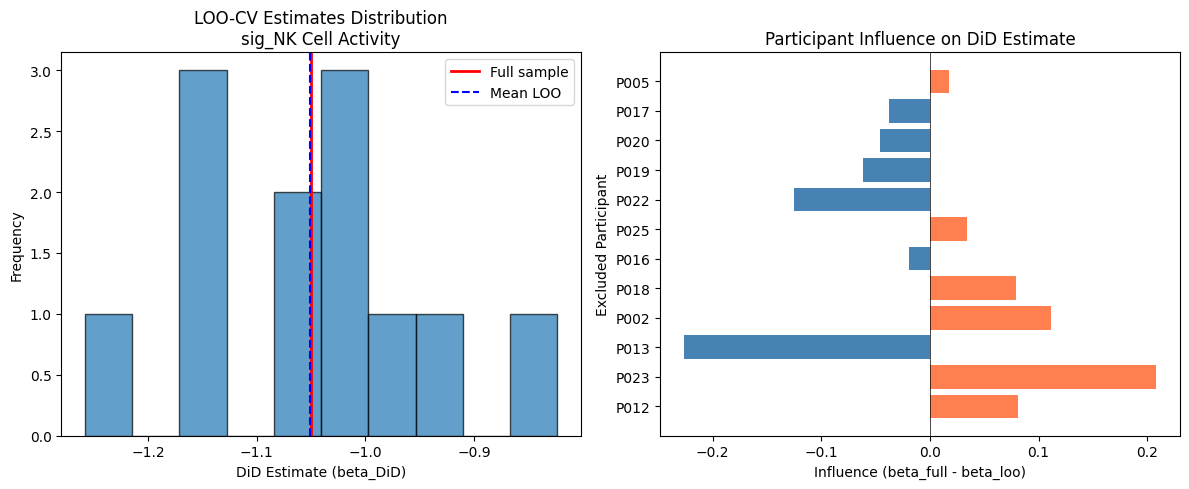

In [73]:
print("=" * 60)
print("CROSS-VALIDATION: EFFECT STABILITY")
print("=" * 60)

if features_use and len(visits) == 2 and len(VALID_PAIRED_ALL) >= 5:
    print(f"\nRunning leave-one-out cross-validation on {len(VALID_PAIRED_ALL)} paired participants...")
    print("This assesses how stable DiD estimates are when each participant is removed.")

    # Use the lead DiD signal (lowest FDR) rather than a fixed index
    if "did_results" in locals() and did_results is not None and not did_results.empty:
        test_feature = did_results.sort_values("FDR_DiD").iloc[0]["feature"]
    else:
        test_feature = features_use[0]
    print(f"\nFeature: {test_feature}")

    try:
        loo_results = st.loo_cv_did(
            adata,
            features=[test_feature],
            design=design,
            visits=tuple(visits),
            aggregate="participant_visit",
            standardize=True,
        )

        if loo_results is not None and not loo_results.empty:
            cv_stats = st.cv_summary(loo_results)

            print("\nLOO-CV Results:")
            print(f"  Full sample beta_DiD: {cv_stats['mean_estimate'].values[0]:.4f}")
            print(f"  Mean LOO beta_DiD:    {cv_stats['mean_loo'].values[0]:.4f}")
            print(f"  Std of LOO estimates: {cv_stats['std_loo'].values[0]:.4f}")
            print(f"  CV (coefficient of variation): {cv_stats['cv'].values[0]:.2%}")

            # Compute influence directly from beta differences
            # (SE-based influence is NaN due to singular covariance)
            full_beta     = cv_stats["mean_estimate"].values[0]
            loo_betas     = loo_results["beta_DiD"].values
            excluded_ids  = loo_results["excluded"].values if "excluded" in loo_results.columns else [f"P{i}" for i in range(len(loo_betas))]
            raw_influence = full_beta - loo_betas  # How much estimate changes when removed

            influence_df = pd.DataFrame({
                "excluded":  excluded_ids,
                "beta_loo":  loo_betas,
                "influence": raw_influence,
            })

            print("\nInfluence Diagnostics (beta_full - beta_loo):")
            display(influence_df.round(4))

            threshold   = 2 * np.nanstd(raw_influence)
            influential = influence_df[influence_df["influence"].abs() > threshold]
            if not influential.empty:
                print(f"\nHighly influential participants (|influence| > 2 SD = {threshold:.3f}):")
                for _, row in influential.iterrows():
                    direction = "increases" if row["influence"] > 0 else "decreases"
                    print(f"  {row['excluded']}: removing {direction} estimate by {abs(row['influence']):.3f}")

            # Visualize LOO estimates
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))

            ax = axes[0]
            ax.hist(loo_betas, bins=10, edgecolor="black", alpha=0.7)
            ax.axvline(full_beta, color="red", linewidth=2, label="Full sample")
            ax.axvline(np.mean(loo_betas), color="blue", linestyle="--", label="Mean LOO")
            ax.set_xlabel("DiD Estimate (beta_DiD)")
            ax.set_ylabel("Frequency")
            ax.set_title(f"LOO-CV Estimates Distribution\n{test_feature}")
            ax.legend()

            ax = axes[1]
            colors = ["coral" if inf > 0 else "steelblue" for inf in raw_influence]
            ax.barh(excluded_ids, raw_influence, color=colors)
            ax.axvline(0, color="black", linewidth=0.5)
            ax.set_xlabel("Influence (beta_full - beta_loo)")
            ax.set_ylabel("Excluded Participant")
            ax.set_title("Participant Influence on DiD Estimate")

            plt.tight_layout()
            plt.show()

        else:
            print("LOO-CV returned no results.")

    except Exception as e:
        print(f"LOO-CV failed: {e}")

else:
    print("Cross-validation requires >= 5 paired participants and valid features.")

### DiDAnalyzer Example
Here we run DiD using the high-level analyzer interface and render a forest plot.

The `DiDAnalyzer` wraps `did_table()` with the same configuration. We pass `DiDConfig(use_bootstrap=True)` so it returns wild cluster bootstrap p-values and CIs, consistent with the primary DiD analysis in Section 7.

DiDAnalyzer Results (wild cluster bootstrap p-values):


,feature,beta_DiD,se_DiD_boot,p_DiD,FDR_DiD,n_units
0,sig_NK Cell Activity,-1.0497,0.6765,0.072,0.6540,12
1,sig_Oxidative Stress Response,0.8511,0.5633,0.109,0.6540,12
2,sig_Cytotoxic T Cell Activity,-1.1525,0.8787,0.166,0.6640,12
3,sig_T Cell Activation,0.7132,0.5906,0.270,0.7611,12
4,sig_Antigen Presentation,-0.9931,1.0149,0.377,0.7611,12
5,sig_Inflammatory Response,0.4824,0.5279,0.429,0.7611,12
6,sig_Cell Proliferation,0.8469,0.9106,0.444,0.7611,12
7,sig_Memory T Cell,-0.1969,0.3937,0.629,0.9435,12
8,sig_Regulatory T Cell,0.0692,0.4447,0.880,0.9520,12
9,sig_Immune Exhaustion,-0.0314,0.2335,0.897,0.9520,12


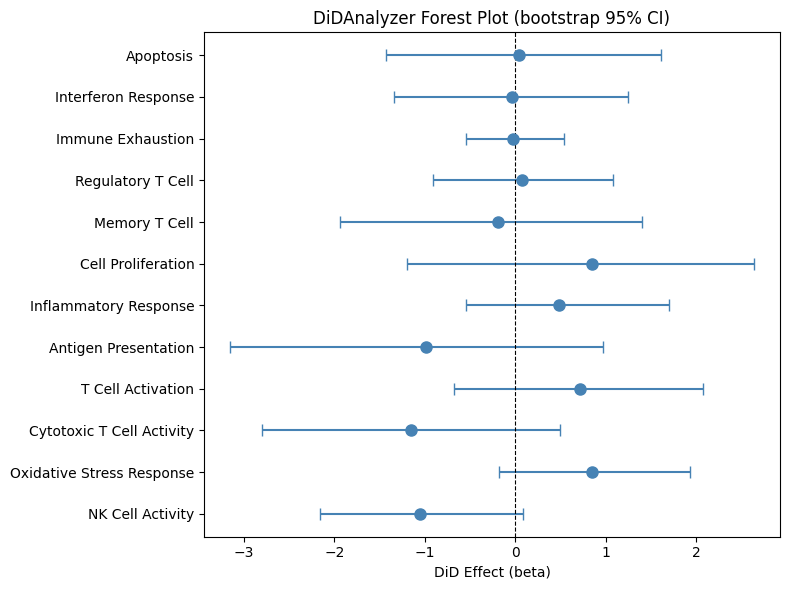

In [74]:
if features_use and len(visits) == 2:
    analyzer = st.DiDAnalyzer(adata, design)
    res_an = analyzer.fit(
        features=features_use,
        visits=tuple(visits),
        config=st.DiDConfig(use_bootstrap=True, n_boot=999, seed=SEED),
    )

    print("DiDAnalyzer Results (wild cluster bootstrap p-values):")
    display_cols = [c for c in ["feature", "beta_DiD", "se_DiD_boot", "p_DiD", "FDR_DiD", "n_units"] if c in res_an.columns]
    display(res_an[display_cols].round(4))

    # Forest plot using bootstrap CIs
    if "ci_lo_boot" in res_an.columns and res_an["ci_lo_boot"].notna().any():
        fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(res_an))))
        y_pos  = range(len(res_an))
        labels = res_an["feature"].str.replace("sig_", "")

        xerr_lo = (res_an["beta_DiD"] - res_an["ci_lo_boot"]).fillna(0)
        xerr_hi = (res_an["ci_hi_boot"] - res_an["beta_DiD"]).fillna(0)
        ax.errorbar(
            res_an["beta_DiD"], y_pos,
            xerr=np.array([xerr_lo, xerr_hi]),
            fmt="o", color="steelblue", capsize=4, markersize=8,
        )
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_yticks(list(y_pos))
        ax.set_yticklabels(labels)
        ax.set_xlabel("DiD Effect (beta)")
        ax.set_title("DiDAnalyzer Forest Plot (bootstrap 95% CI)")

        # Mark significant
        for i, (_, row) in enumerate(res_an.iterrows()):
            if pd.notna(row.get("FDR_DiD")) and row["FDR_DiD"] < FDR_ALPHA:
                ax.annotate("*", (row["beta_DiD"], i), fontsize=16, fontweight="bold",
                           xytext=(5, 5), textcoords="offset points")
        plt.tight_layout()
        plt.show()
    else:
        print("Forest plot skipped: no valid bootstrap CIs available.")
else:
    print("Skipping DiDAnalyzer: insufficient features or visits")

### Model Diagnostics (Residual Checks)
We fit a simple DiD model for the lead feature and check residual diagnostics.

{'bp_pvalue': 0.031130059512438846, 'jb_pvalue': 0.5890449767758577, 'resid_mean': 2.6309972718981573e-17, 'resid_std': 0.027439226541361637}


/var/folders/xl/pr40r62n3wx54s8_6cgjzg2c0000gt/T/ipykernel_1052/371620226.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


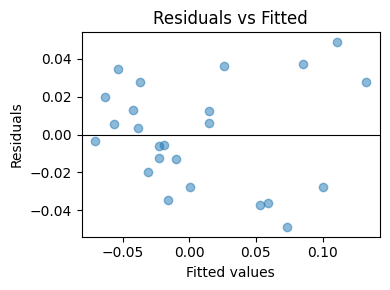

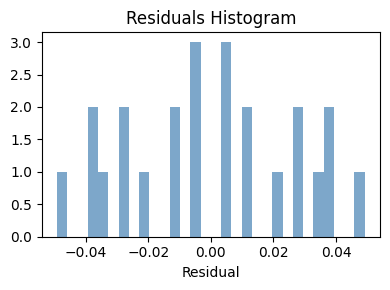

In [75]:
if features_use and len(visits) == 2:
    # Use the lead DiD signal (lowest FDR) for diagnostics
    if "did_results" in locals() and did_results is not None and not did_results.empty:
        feat = did_results.sort_values("FDR_DiD").iloc[0]["feature"]
    else:
        feat = features_use[0]
    df = adata.obs[[design.participant_col, design.visit_col, design.arm_col]].copy()
    df[feat] = adata.obs[feat].values
    df = df[df[design.visit_col].isin(visits)]
    df = df.groupby([design.participant_col, design.visit_col, design.arm_col], observed=True)[feat].mean().reset_index()
    # Encode visits as numeric 0/1 for OLS formula
    df["visit_num"] = df[design.visit_col].map({visits[0]: 0, visits[1]: 1}).astype(float)
    df["arm_bin"]   = (df[design.arm_col] == design.arm_treated).astype(int)
    # Rename outcome to avoid patsy parse errors: signature names contain spaces
    df = df.rename(columns={feat: "_y"})
    import statsmodels.formula.api as smf
    fit  = smf.ols(f"_y ~ visit_num + visit_num:arm_bin + C({design.participant_col})", data=df).fit()
    diag = st.check_did_assumptions(fit, return_figures=True)
    print({k: v for k, v in diag.items() if k != "figures"})
    for fig in diag.get("figures", {}).values():
        fig.tight_layout()
        fig.show()

### Treatment Heterogeneity
Here we test whether the DiD effect differs by a baseline biomarker (median split at baseline).

**Caveat:** The biomarker is the baseline (Pre-treatment) mean of the first feature. Participants without a Pre-treatment observation will have NaN biomarker values, which are dropped during model fitting. With small n, even one missing value substantially reduces power. Interpret heterogeneity results cautiously.


In [76]:
if features_use and len(visits) == 2:
    # Compute baseline biomarker for the first feature (used as the splitting variable)
    feat_biomarker = features_use[0]
    base = adata.obs[adata.obs[design.visit_col] == visits[0]].copy()
    biomarker = base.groupby(design.participant_col)[feat_biomarker].mean()
    adata.obs['biomarker_base'] = adata.obs[design.participant_col].map(biomarker)

    # Test heterogeneity for ALL features
    res_het = st.test_treatment_heterogeneity(
        adata,
        features=features_use,
        design=design,
        visits=tuple(visits),
        biomarker_col='biomarker_base',
    )
    print(f"Biomarker: baseline {feat_biomarker} (median split)")
    display(res_het.round(4))

    sig_het = res_het[res_het["FDR_heterogeneity"] < FDR_ALPHA]
    if not sig_het.empty:
        print(f"\nSignificant heterogeneity (FDR < {FDR_ALPHA}):")
        for _, row in sig_het.iterrows():
            print(f"  {row['feature']}: beta={row['beta_heterogeneity']:.3f}, FDR={_fmt_fdr(row['FDR_heterogeneity'])}")
    else:
        print(f"\nNo significant treatment heterogeneity detected (FDR < {FDR_ALPHA}).")
        print("This is expected given the small sample size.")

Biomarker: baseline sig_Cytotoxic T Cell Activity (median split)


,feature,beta_heterogeneity,p_heterogeneity,n_units,threshold,FDR_heterogeneity
0,sig_Cytotoxic T Cell Activity,2.1721,0.3271,12,-0.0901,0.8623
1,sig_Immune Exhaustion,1.4637,0.5060,12,-0.0901,0.8623
2,sig_Interferon Response,0.8638,0.6273,12,-0.0901,0.8623
3,sig_Memory T Cell,-0.2679,0.8623,12,-0.0901,0.8623
4,sig_T Cell Activation,0.5906,0.8166,12,-0.0901,0.8623
5,sig_Inflammatory Response,-0.5989,0.8339,12,-0.0901,0.8623
6,sig_Antigen Presentation,2.8778,0.2728,12,-0.0901,0.8623
7,sig_Cell Proliferation,-1.2243,0.5313,12,-0.0901,0.8623
8,sig_Regulatory T Cell,1.8513,0.3342,12,-0.0901,0.8623
9,sig_NK Cell Activity,1.1966,0.4399,12,-0.0901,0.8623



No significant treatment heterogeneity detected (FDR < 0.25).
This is expected given the small sample size.


### Sensitivity to Unmeasured Confounding (E-value)
The E-value measures how strong unmeasured confounding would need to be to explain away an observed association. We convert the delta-based Hedge's g (from the Effect Sizes section) to an approximate risk ratio using the formula RR = exp(0.91 * g), which is valid for continuous outcomes.


In [77]:
if did_results is not None and not did_results.empty:
    # Use delta-based Hedge's g (from Effect Size section) rather than
    # regression-based effect_size, which uses a different denominator.
    lead_feature = did_results.iloc[0]["feature"]

    # Look up delta-based Hedge's g if available
    if "df_effect" in locals() and not df_effect.empty:
        match = df_effect[df_effect["feature"] == lead_feature]
        if not match.empty:
            g_val = abs(float(match.iloc[0]["hedges_g"]))
        else:
            g_val = abs(float(did_results.iloc[0].get("effect_size", did_results.iloc[0]["beta_DiD"])))
    else:
        g_val = abs(float(did_results.iloc[0].get("effect_size", did_results.iloc[0]["beta_DiD"])))

    # Convert to approximate RR via VanderWeele & Ding (2017):
    # RR ~ exp(0.91 * |d|) for continuous outcomes
    rr = float(np.exp(0.91 * g_val))

    e_val, e_ci = st.e_value_rr(rr)
    print(f"Feature: {lead_feature}")
    print(f"  |Effect size| = {g_val:.3f}")
    print(f"  Approximate RR = exp(0.91 * {g_val:.3f}) = {rr:.3f}")
    print(f"  E-value = {e_val:.3f}")
    if e_ci is not None:
        print(f"  E-value (CI bound) = {e_ci:.3f}")
    print(f"\n  Interpretation: An unmeasured confounder would need to be associated")
    print(f"  with both treatment and outcome by a risk ratio of at least {e_val:.2f}")
    print(f"  to explain away this observed effect.")

Feature: sig_NK Cell Activity
  |Effect size| = 1.096
  Approximate RR = exp(0.91 * 1.096) = 2.712
  E-value = 4.866

  Interpretation: An unmeasured confounder would need to be associated
  with both treatment and outcome by a risk ratio of at least 4.87
  to explain away this observed effect.


### Bayesian DiD Forest Plot
Here we visualize Bayesian DiD effect estimates (posterior means with 95% credible intervals). Interpreting the plot: Coefficients are on a standardized outcome scale (SD units) because standardize=True is used in the Bayesian fit. Intervals excluding zero indicate a directional posterior signal, but consult the p_bayes and FDR_bayes columns for multiplicity-adjusted evidence (e.g., a 95% CI excluding zero with FDR_bayes > 0.05 is exploratory at best).

If PyMC is not installed, we fall back to the frequentist DiD forest plot using wild cluster bootstrap p-values and 95% CIs from Section 7.

In [78]:
# Bayesian DiD (PyMC)
#
# NOTE: On some systems, PyTensor may fail to compile C extensions (arch mismatch).
# We force a fresh, writable compiledir and disable C compilation to avoid
# stale x86_64 artifacts on arm64.
import os
import logging
import tempfile

os.environ["PYTENSOR_FLAGS"] = f"compiledir={tempfile.mkdtemp(prefix='pytensor_')},cxx="
logging.getLogger("pytensor").setLevel(logging.ERROR)

try:
    import pymc  # noqa: F401

    bayes_res = st.did_table_bayes(
        adata,
        features=features_use,
        design=design,
        visits=tuple(visits),
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        max_treedepth=12,
        seed=SEED,
    )
    display(bayes_res)

    print("Bayesian DiD note: For small samples, convergence diagnostics may be noisy.")
    print("If rhat > 1.01 or ESS is low, increase draws/tune or consider stronger priors.")
except ImportError:
    print("PyMC not installed; skip Bayesian DiD. Install with: pip install 'sctrial[bayes]'")
    bayes_res = None
except Exception as e:
    print("Bayesian DiD failed due to PyMC/PyTensor runtime error.")
    print(f"Reason: {type(e).__name__}: {e}")
    bayes_res = None

,feature,beta_DiD,ci_low,ci_high,p_bayes,n_units,FDR_bayes
0,sig_Cell Proliferation,0.774688,-0.176277,1.658015,0.0995,12,0.476400
1,sig_T Cell Activation,0.774428,-0.279946,1.756402,0.1275,12,0.476400
2,sig_NK Cell Activity,-0.686971,-1.524283,0.243049,0.1410,12,0.476400
3,sig_Cytotoxic T Cell Activity,-0.757955,-1.773825,0.373930,0.1770,12,0.476400
4,sig_Oxidative Stress Response,0.613247,-0.346605,1.490971,0.1985,12,0.476400
5,sig_Inflammatory Response,0.479936,-0.518683,1.373072,0.3005,12,0.601000
6,sig_Memory T Cell,-0.268652,-0.917117,0.431614,0.4025,12,0.619500
7,sig_Interferon Response,0.404082,-0.629197,1.396465,0.4130,12,0.619500
8,sig_Regulatory T Cell,0.164112,-0.910466,1.183019,0.7375,12,0.897273
9,sig_Immune Exhaustion,0.116073,-0.974884,1.141472,0.8205,12,0.897273


Bayesian DiD note: For small samples, convergence diagnostics may be noisy.
If rhat > 1.01 or ESS is low, increase draws/tune or consider stronger priors.


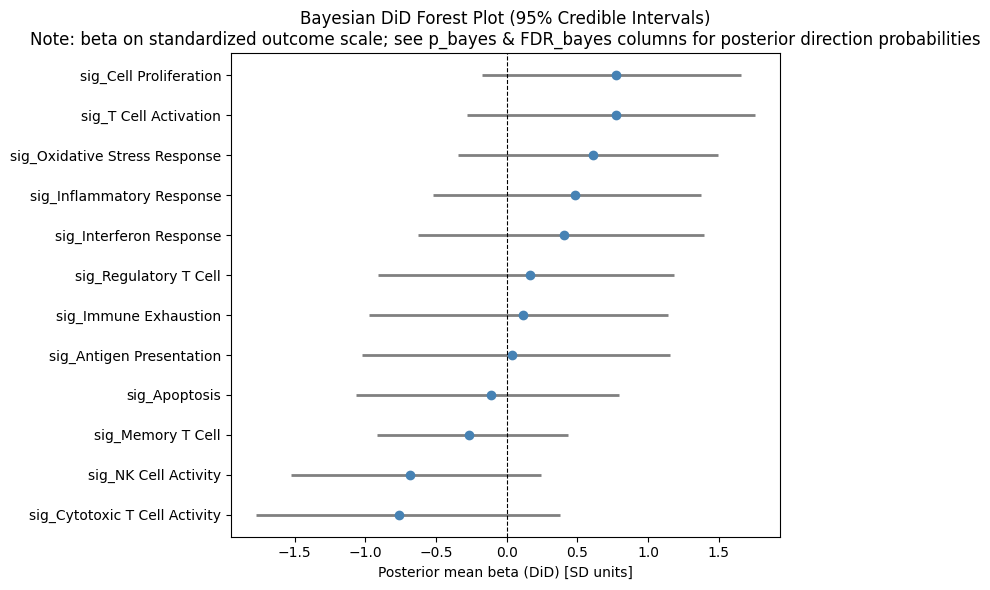

In [79]:
# Bayesian DiD forest plot (uses posterior credible intervals)
# Falls back to frequentist DiD (wild cluster bootstrap) if PyMC is not installed
has_bayes = "bayes_res" in locals() and bayes_res is not None and not bayes_res.empty
has_freq  = "did_results" in locals() and did_results is not None and not did_results.empty

if has_bayes:
    try:
        df_forest = bayes_res.copy().sort_values("beta_DiD")
        ci_lo, ci_hi = df_forest["ci_low"], df_forest["ci_high"]
        title  = "Bayesian DiD Forest Plot (95% Credible Intervals)\nNote: beta on standardized outcome scale; see p_bayes & FDR_bayes columns for posterior direction probabilities"
        xlabel = "Posterior mean beta (DiD) [SD units]"
    except Exception as e:
        print(f"Bayesian forest plot failed: {e}")
        has_bayes = False

if not has_bayes and has_freq:
    print("PyMC not available -- showing frequentist DiD forest plot instead.\n")
    df_forest = did_results.copy().sort_values("beta_DiD")
    ci_lo  = df_forest["ci_lo_boot"]
    ci_hi  = df_forest["ci_hi_boot"]
    title  = "DiD Forest Plot (wild cluster bootstrap 95% CI)"
    xlabel = "beta DiD (bootstrap p-values)"

if has_bayes or has_freq:
    fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(df_forest))))
    y = range(len(df_forest))
    ax.hlines(y, ci_lo, ci_hi, color="gray", linewidth=2)
    ax.plot(df_forest["beta_DiD"], y, "o", color="steelblue")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_yticks(list(y))
    ax.set_yticklabels(df_forest["feature"])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
else:
    print("No DiD results available for forest plot.")